# Simulation Output Raster Plots

Load spike data written by the NEST cortical-column simulation (`run_multi_delay_stim_sim.py`) and plot spike rasters for the baseline and paired-stimulation conditions.

## 1 — Import Required Libraries

In [114]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Local modules (helpers, corcol_params, etc.) live in the workspace root.
# Jupyter kernels default to the notebook directory so no sys.path changes needed.
import helpers
from corcol_params.network_params import net_dict
from corcol_params.sim_params import sim_dict

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 2 — Define Paths and Parameters

In [ ]:
# ── Stimulation config (must match run_multi_delay_stim_sim.py) ─────────────
GAP_MS          = 1000  # ms — gap between consecutive pairs
STIM_AMPLITUDES = [2]   # uA
SEQ_DELAY_MS_LIST = [0, 5, 10, 15, 20, 30, 40, 50, 100, 200, 300]   # ms — all delay conditions to plot

# ── Derived sim parameters from corcol param files ───────────────────────────
Nscale     = net_dict["N_scaling"]
sim_time_s = int(sim_dict["t_sim"] / 1000)
stim_amp   = STIM_AMPLITUDES[0]

PRESIM_TIME_MS = sim_dict["t_presim"]
SIM_TIME_MS    = sim_dict["t_sim"]

# Window to display in the raster (ms)
RASTER_DURATION_MS = 1500
RASTER_INTERVAL    = [PRESIM_TIME_MS, PRESIM_TIME_MS + RASTER_DURATION_MS]

# ── Output directory layout (matches run_multi_delay_stim_sim.py) ─────────────
WORKSPACE     = os.getcwd()
base_path     = os.path.join(
    WORKSPACE, "outputs",
    f"data_multi_delay_{Nscale}scale_{stim_amp}uA_{sim_time_s}s",
)
baseline_path = os.path.join(base_path, "data_baseline")

print("base_path    :", base_path)
print("baseline_path:", baseline_path)
print("delay list   :", SEQ_DELAY_MS_LIST)

# ── Population labels (8 populations: 4 layers × E/I) ────────────────────────
POP_LABELS = ["L2/3E", "L2/3I", "L4E", "L4I", "L5E", "L5I", "L6E", "L6I"]
POP_COLORS = np.tile(["#595289", "#af143c"], 4)


base_path    : /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s
baseline_path: /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_baseline
delay list   : [0, 5, 10, 20, 30, 40, 50, 100, 200, 300]


## 3 — Load Spike Train Data

Reconstruct per-neuron spike train lists from the `.dat` spike recorder files, exactly as `network.get_spike_train_list()` does at runtime. Also load the stim pulse times saved to `stim_pulses.pkl`.

In [116]:
from itertools import groupby


def load_spike_train_list(data_path):
    """
    Replicate network.get_spike_train_list() offline from .dat files.

    Returns
    -------
    spk_trains : list[np.ndarray]  — one array per neuron (neuron index 0-based)
    node_ids   : np.ndarray shape (n_pops, 2) — [first_node, last_node] per pop
    """
    sd_names, node_ids, data = helpers.load_spike_times(
        data_path, "spike_recorder", 0, np.inf
    )
    last_node_id = node_ids[-1, -1]
    n_neurons = int(last_node_id - node_ids[0, 0] + 1)

    all_neuron_stamps = {}
    for i_pop, _ in enumerate(sd_names):
        times   = data[i_pop]["time_ms"]
        neurons = np.abs(data[i_pop]["sender"] - last_node_id) + 1
        for neuron_id, idx_iter in groupby(
            sorted(range(len(neurons)), key=neurons.__getitem__),
            key=neurons.__getitem__,
        ):
            all_neuron_stamps[neuron_id] = times[list(idx_iter)]

    spk_trains = [np.array([]) for _ in range(n_neurons)]
    for nid, times in all_neuron_stamps.items():
        if 1 <= nid <= n_neurons:
            spk_trains[nid - 1] = np.array(times)

    return spk_trains, node_ids


# ── Load baseline once ────────────────────────────────────────────────────────
baseline_spk_trains, node_ids = load_spike_train_list(baseline_path)
print(f"Baseline: {len(baseline_spk_trains)} neurons loaded")

Baseline: 3858 neurons loaded


## 4 — Parse Spike Trains by Population

Map raw node IDs back to population labels so each spike can be colour-coded.

In [117]:
def get_population_spikes(spk_trains, node_ids, interval_ms):
    """
    Map spike trains to populations using the same neuron_id transform as
    network.get_spktrains():  neuron_id = abs(sender - last_node_id) + 1

    L2/3E (lowest senders) → highest neuron_ids
    L6I   (highest senders) → neuron_ids 1…N_L6I
    """
    last_node_id = node_ids[-1, -1]
    t0, t1 = interval_ms

    pop_spikes = []
    for i in range(len(node_ids)):
        nid_lo = int(last_node_id - node_ids[i, 1] + 1)
        nid_hi = int(last_node_id - node_ids[i, 0] + 1)

        times_list, nids_list = [], []
        for nid in range(nid_lo, nid_hi + 1):
            if nid < 1 or nid > len(spk_trains):
                continue
            st = spk_trains[nid - 1]
            if len(st) == 0:
                continue
            mask = (st >= t0) & (st <= t1)
            times_list.append(st[mask])
            nids_list.append(np.full(mask.sum(), nid))

        pop_spikes.append({
            "times":           np.concatenate(times_list) if times_list else np.array([]),
            "neuron_ids":      np.concatenate(nids_list)  if nids_list  else np.array([]),
            "neuron_id_range": (nid_lo, nid_hi),
        })
    return pop_spikes


def plot_raster_ax(ax, pop_spikes, ytick_pos, ylim_overall, title=None, xlabel=True):
    """Draw a spike raster on ax, colour-coded by population."""
    for label, p, color in zip(POP_LABELS, pop_spikes, POP_COLORS):
        if len(p["times"]) > 0:
            ax.plot(p["times"], p["neuron_ids"], "|", color=color,
                    markersize=1, label=label)
    ax.set_xlim(RASTER_INTERVAL)
    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(POP_LABELS, fontsize=9)
    ax.set_ylim(ylim_overall)
    if xlabel:
        ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Population")
    if title:
        ax.set_title(title, fontsize=10)


# ── Baseline populations (computed once, reused for every plot) ───────────────
baseline_pops = get_population_spikes(baseline_spk_trains, node_ids, RASTER_INTERVAL)
ytick_pos    = [(p["neuron_id_range"][0] + p["neuron_id_range"][1]) / 2 for p in baseline_pops]
ylim_overall = (1, max(p["neuron_id_range"][1] for p in baseline_pops))

print("Population neuron_id ranges:")
for label, p in zip(POP_LABELS, baseline_pops):
    lo, hi = p["neuron_id_range"]
    print(f"  {label:6s}: {lo:5d} – {hi:5d}  |  baseline spikes: {len(p['times'])}")

Population neuron_id ranges:
  L2/3E :  2825 –  3858  |  baseline spikes: 491
  L2/3I :  2533 –  2824  |  baseline spikes: 609
  L4E   :  1437 –  2532  |  baseline spikes: 5423
  L4I   :  1163 –  1436  |  baseline spikes: 1588
  L5E   :   921 –  1162  |  baseline spikes: 1984
  L5I   :   868 –   920  |  baseline spikes: 539
  L6E   :   148 –   867  |  baseline spikes: 566
  L6I   :     1 –   147  |  baseline spikes: 1334


## 5 — Plot Baseline Spike Raster

Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_baseline/raster_baseline.png


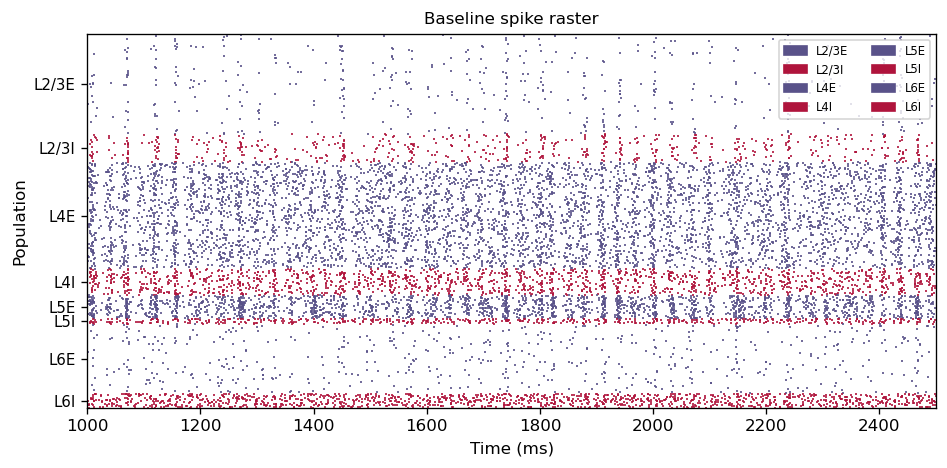

In [118]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_raster_ax(ax, baseline_pops, ytick_pos, ylim_overall, title="Baseline spike raster")
handles = [mpatches.Patch(color=c, label=l) for c, l in zip(POP_COLORS, POP_LABELS)]
ax.legend(handles=handles, loc="upper right", fontsize=7, ncol=2)
plt.tight_layout()

save_path = os.path.join(baseline_path, "raster_baseline.png")
plt.savefig(save_path, dpi=150)
print(f"Saved → {save_path}")
plt.show()

## 6 — Plot Rasters for All Delays

For each delay condition, load the stim spike trains and pulse times, then produce and save two figures:
1. **Stim + pulse overlay** — 2-panel (spike raster / electrode sub-raster)  
2. **Baseline vs Stim side-by-side**


── delay = 0 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_0ms/raster_stim_pulses_0ms.png


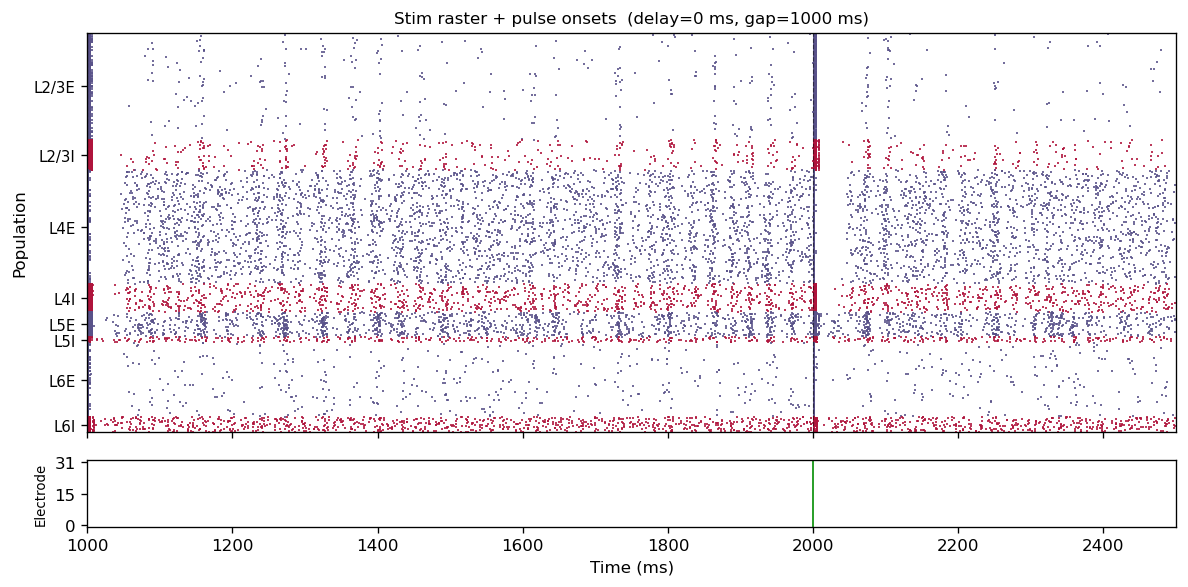

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_0ms/raster_baseline_vs_stim_0ms.png


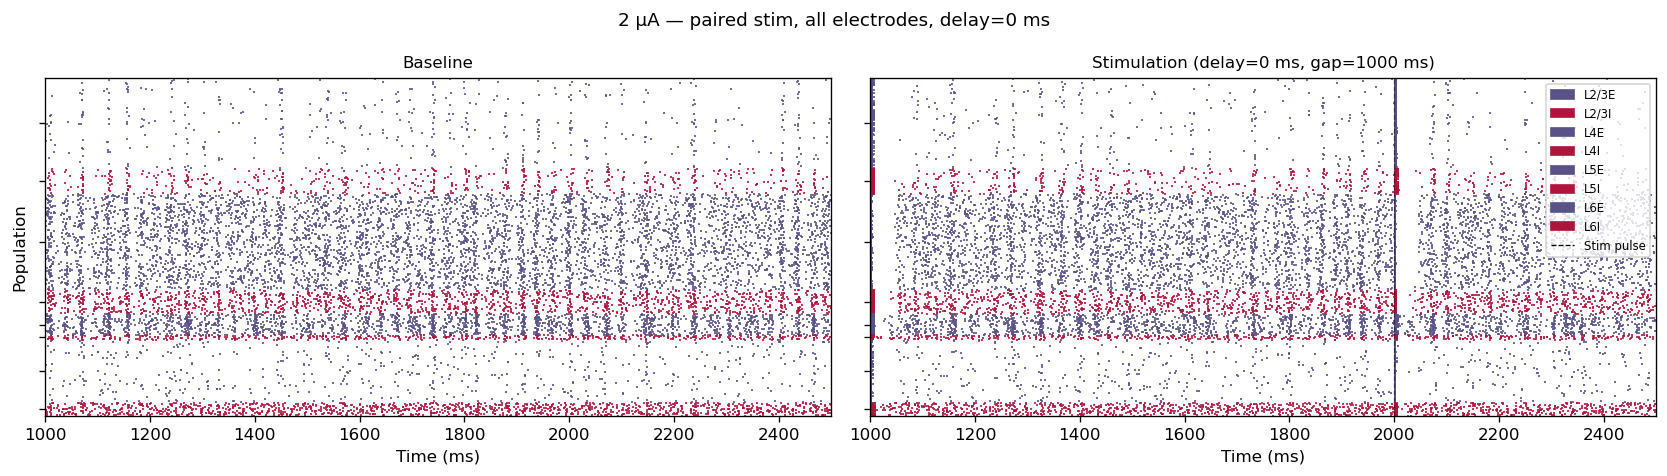


── delay = 5 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_5ms/raster_stim_pulses_5ms.png


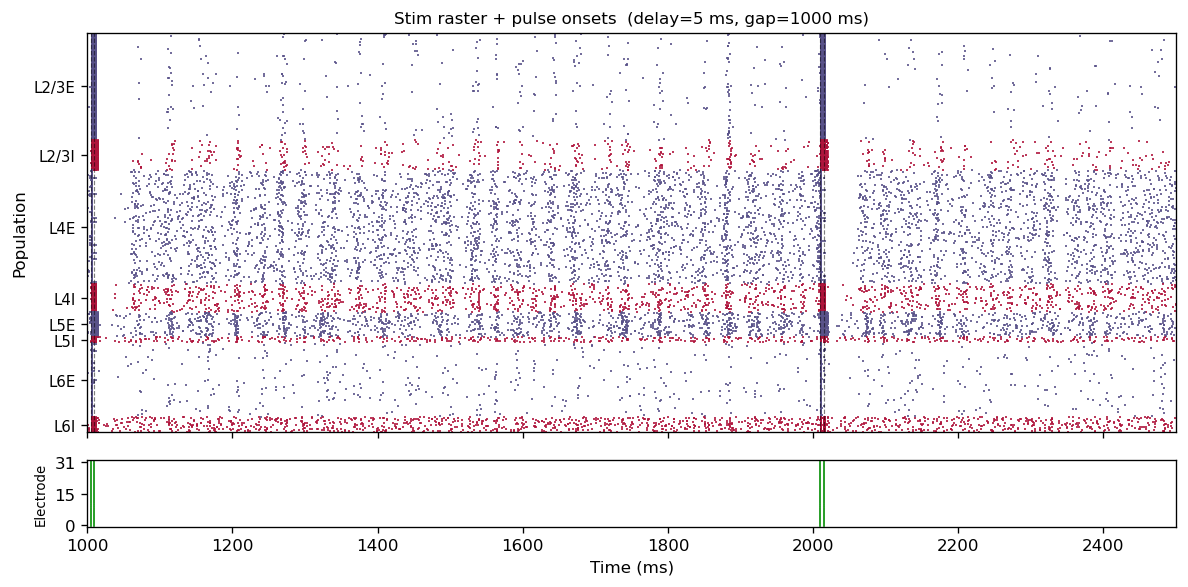

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_5ms/raster_baseline_vs_stim_5ms.png


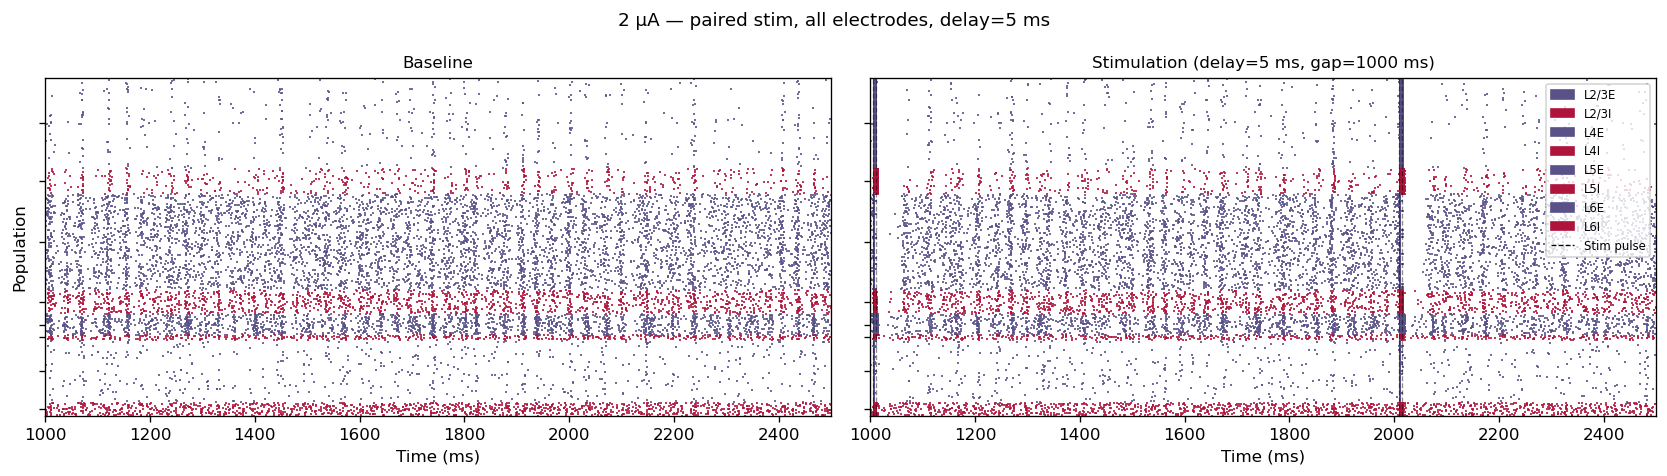


── delay = 10 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_10ms/raster_stim_pulses_10ms.png


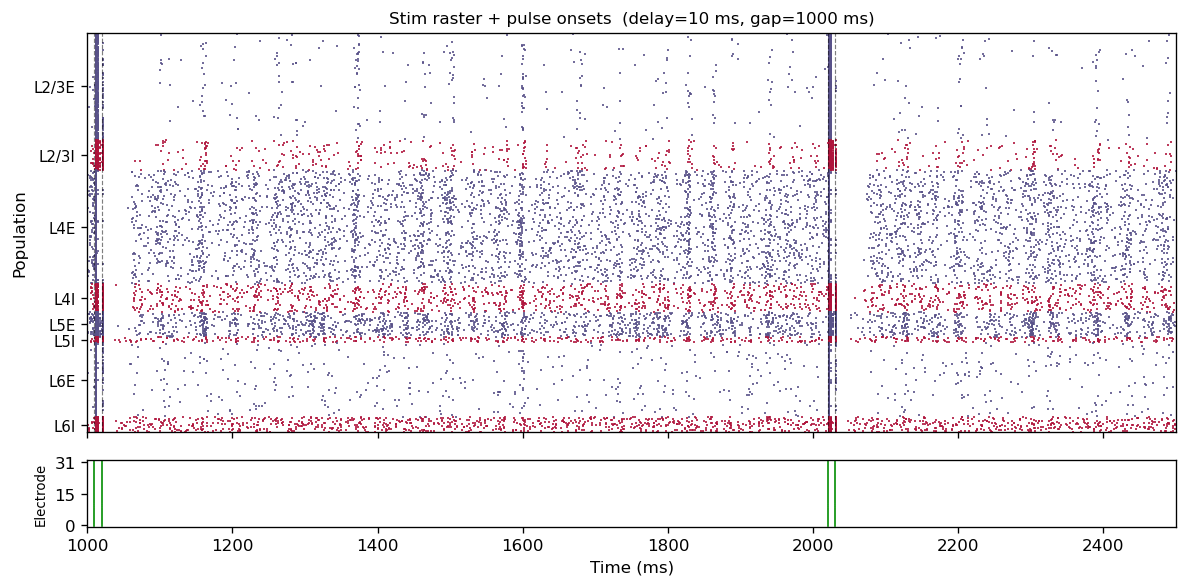

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_10ms/raster_baseline_vs_stim_10ms.png


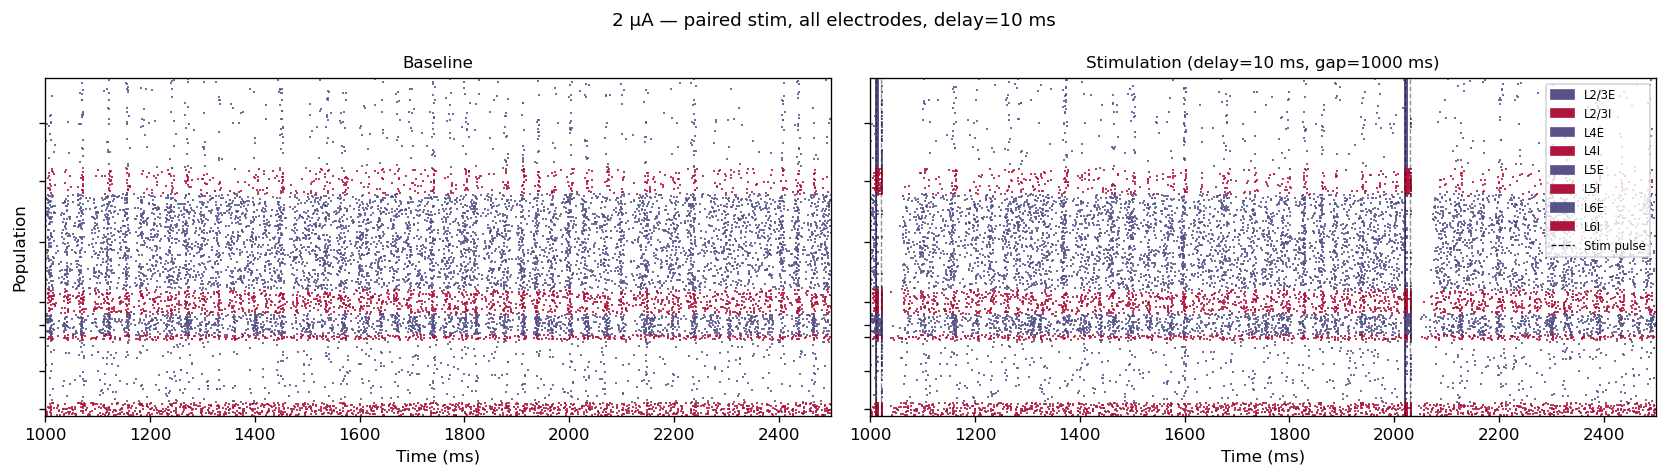


── delay = 20 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_20ms/raster_stim_pulses_20ms.png


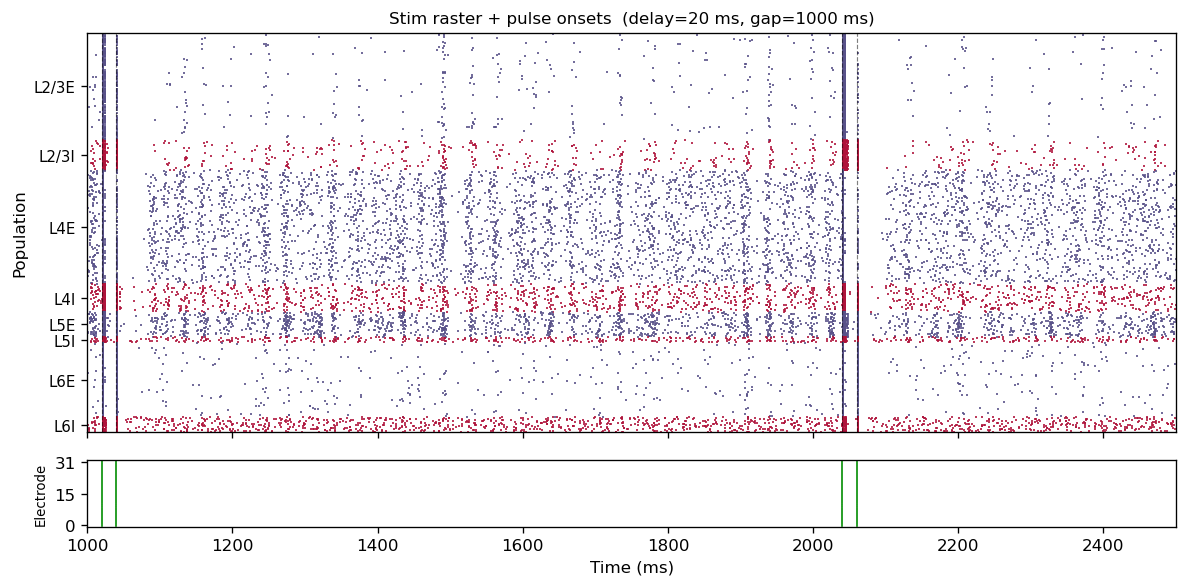

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_20ms/raster_baseline_vs_stim_20ms.png


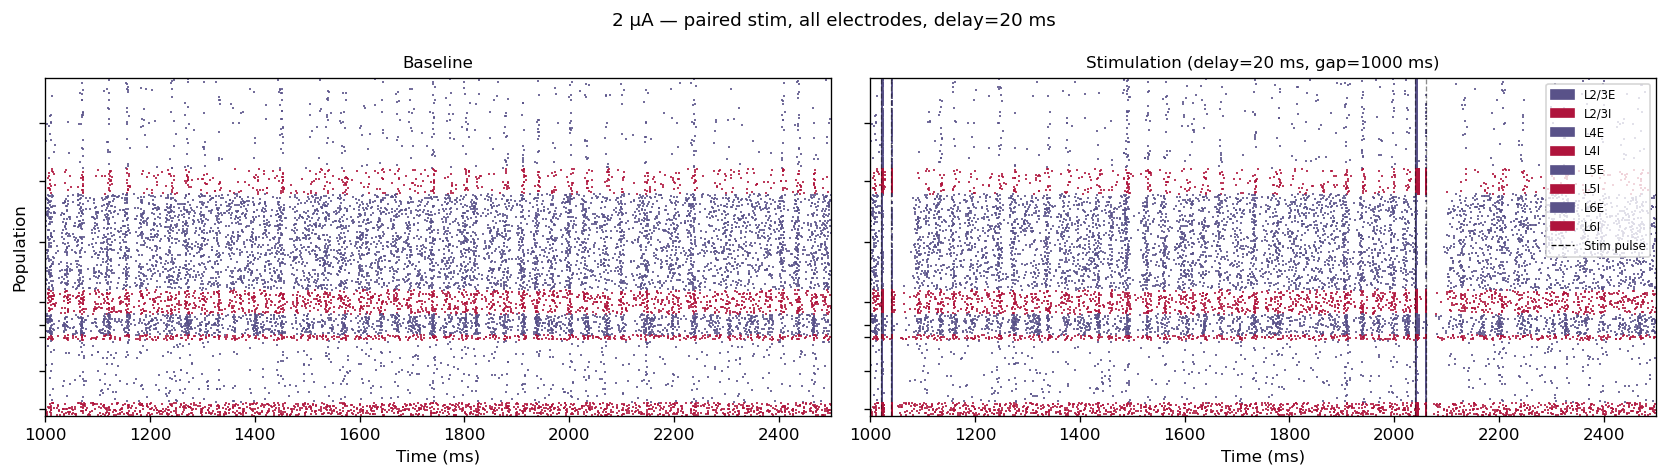


── delay = 30 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_30ms/raster_stim_pulses_30ms.png


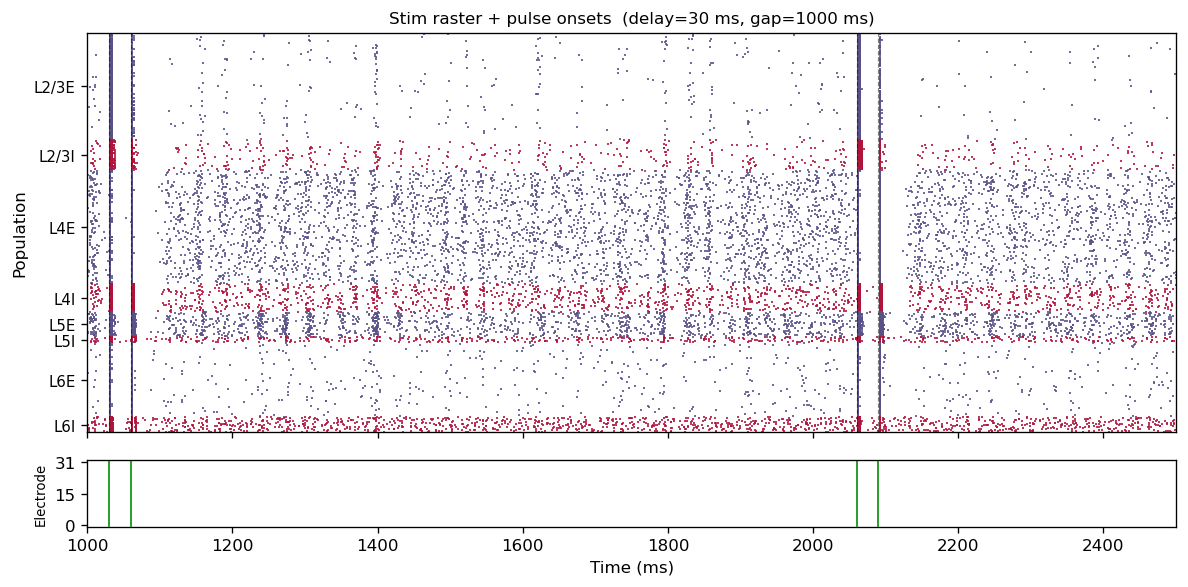

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_30ms/raster_baseline_vs_stim_30ms.png


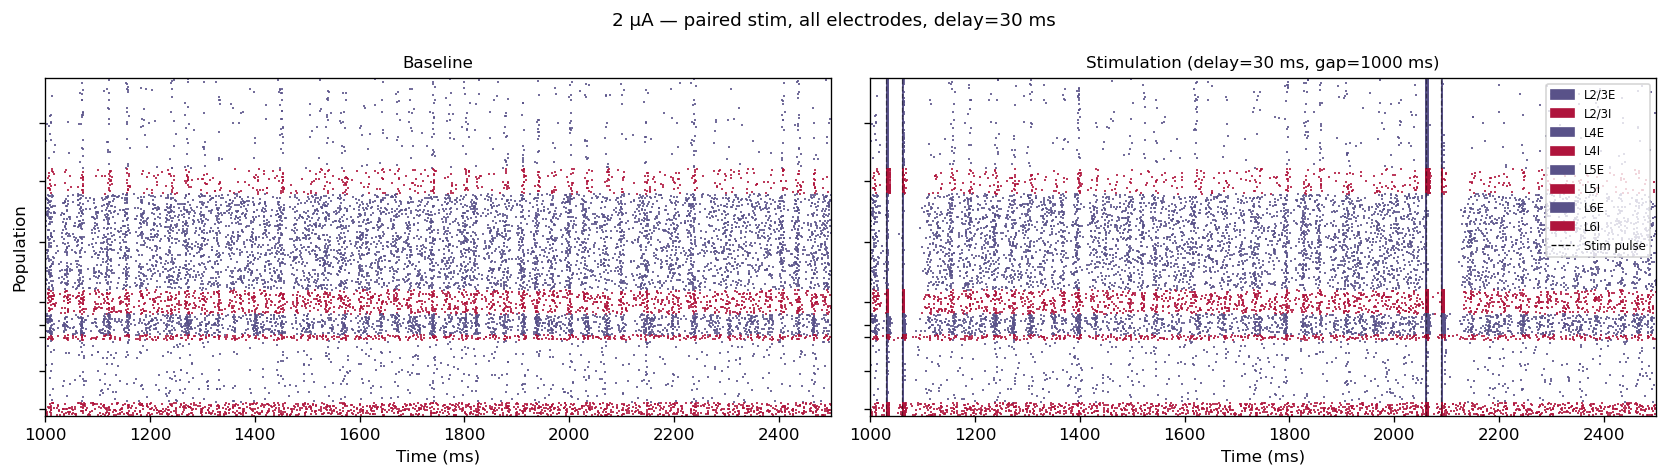


── delay = 40 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_40ms/raster_stim_pulses_40ms.png


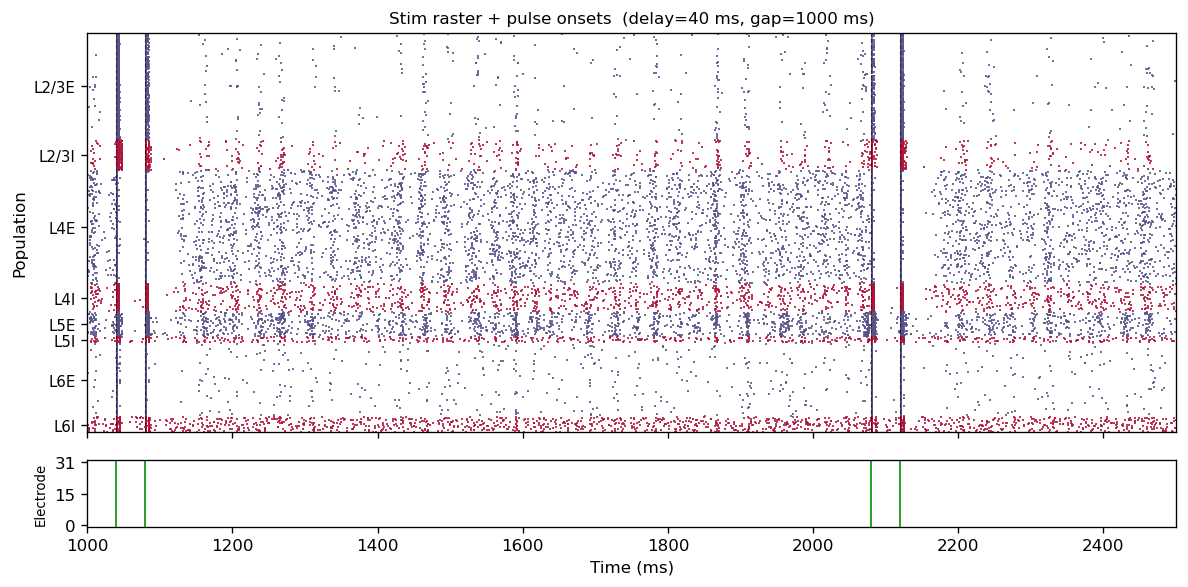

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_40ms/raster_baseline_vs_stim_40ms.png


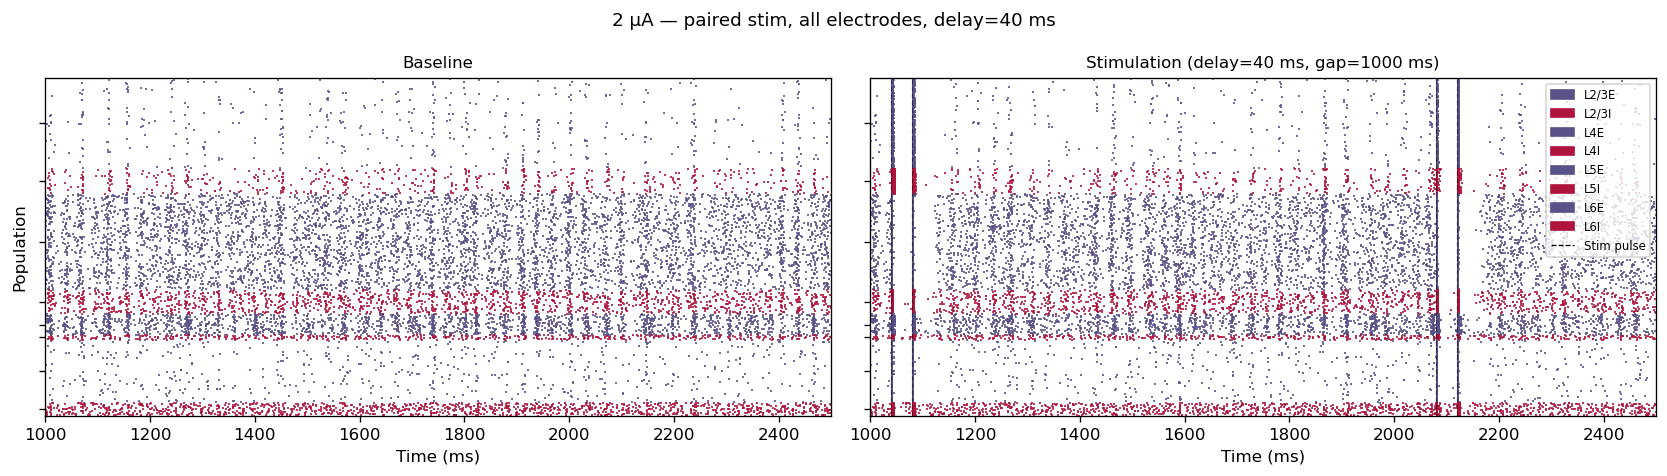


── delay = 50 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_50ms/raster_stim_pulses_50ms.png


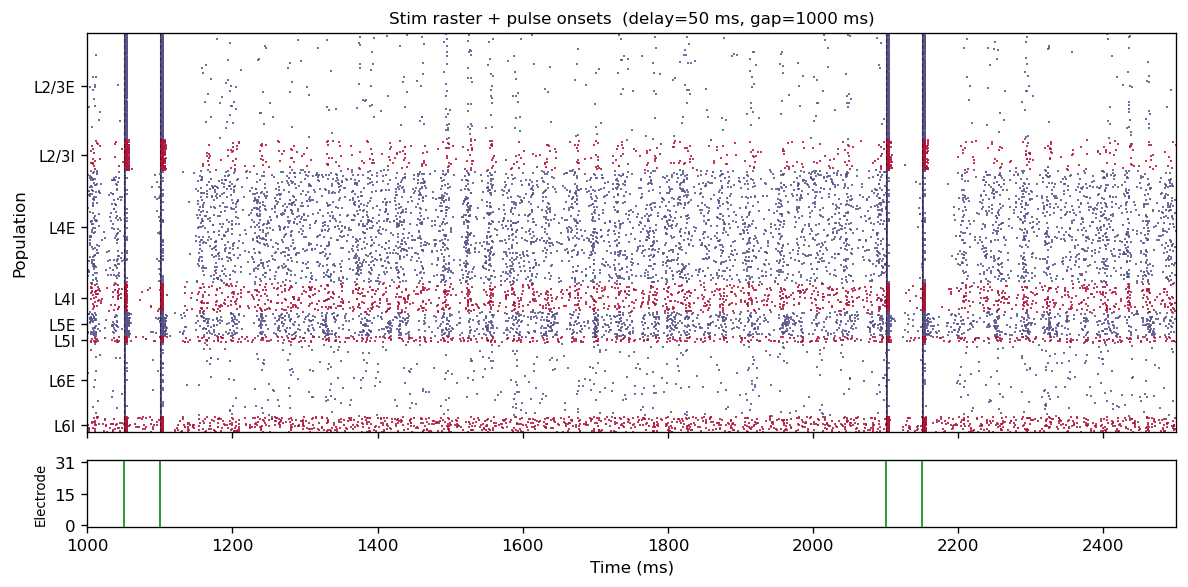

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_50ms/raster_baseline_vs_stim_50ms.png


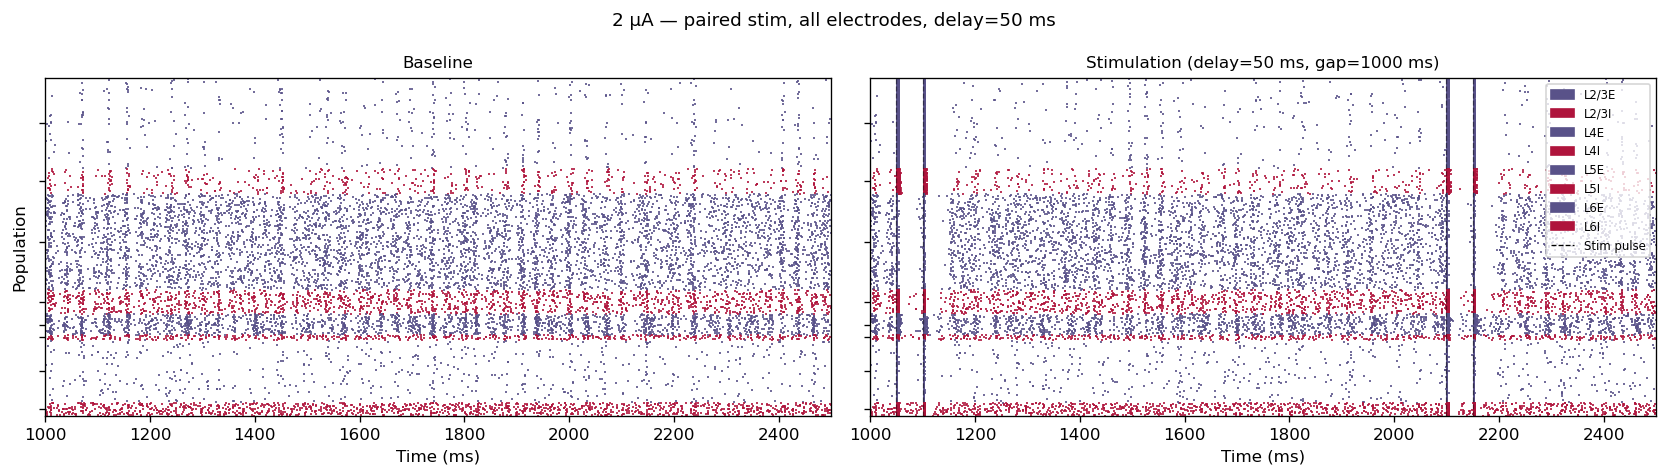


── delay = 100 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_100ms/raster_stim_pulses_100ms.png


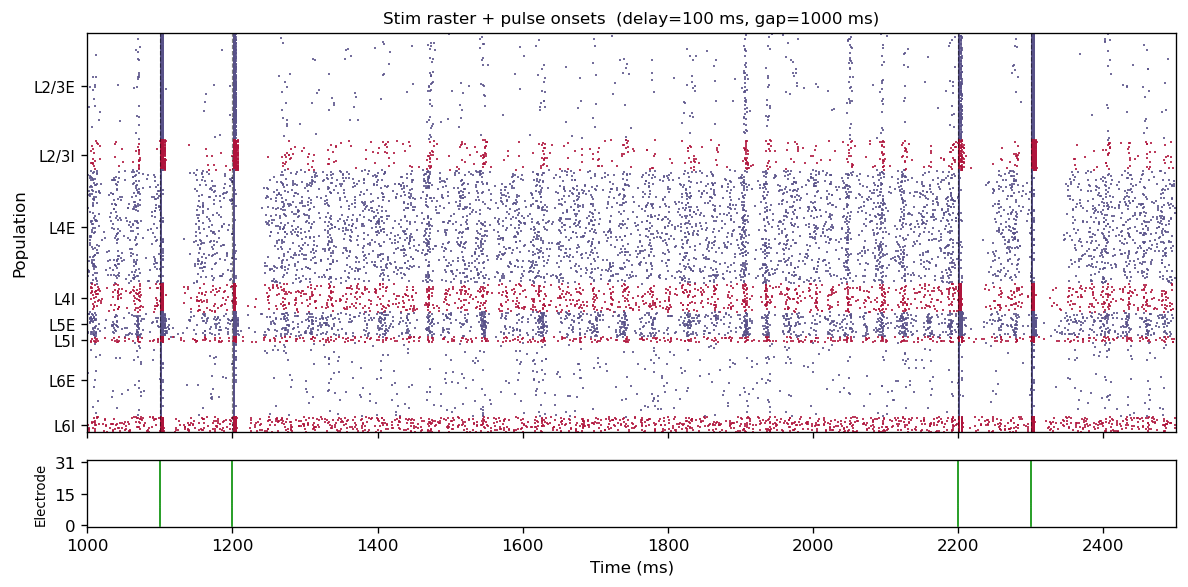

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_100ms/raster_baseline_vs_stim_100ms.png


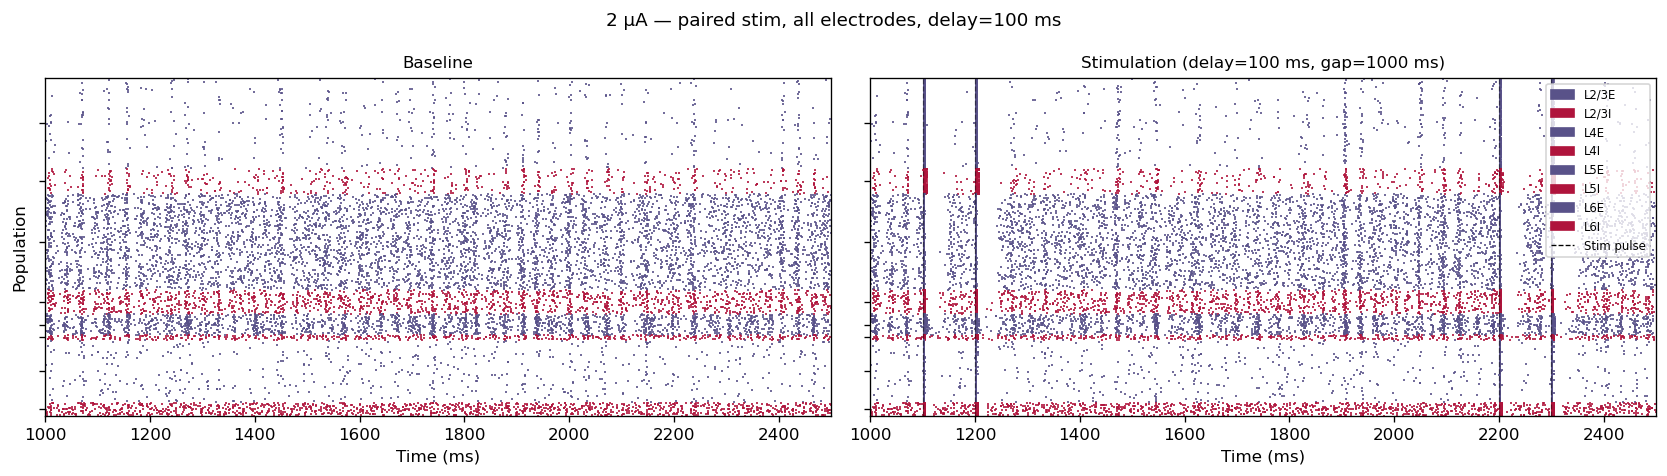


── delay = 200 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_200ms/raster_stim_pulses_200ms.png


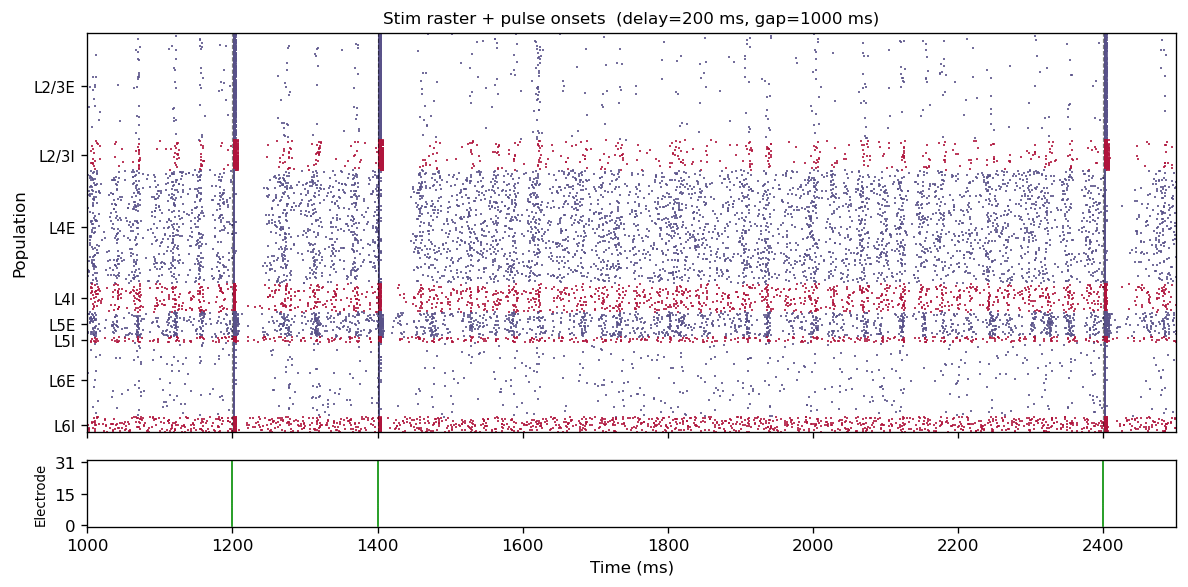

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_200ms/raster_baseline_vs_stim_200ms.png


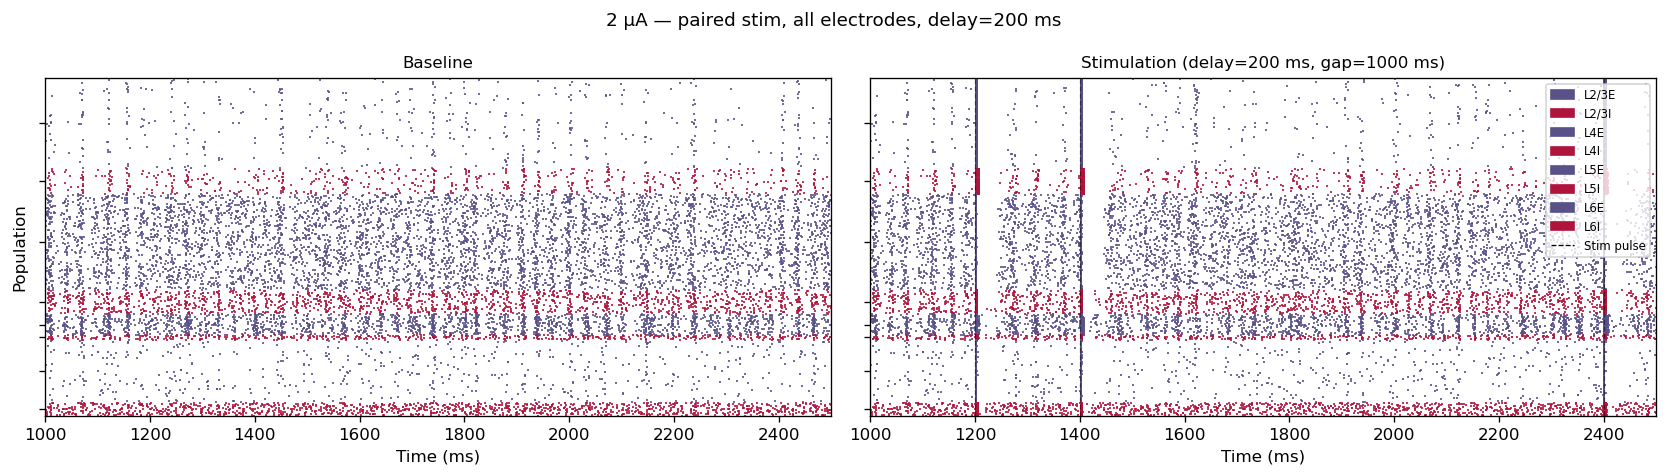


── delay = 300 ms ──────────────────────────────────
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_300ms/raster_stim_pulses_300ms.png


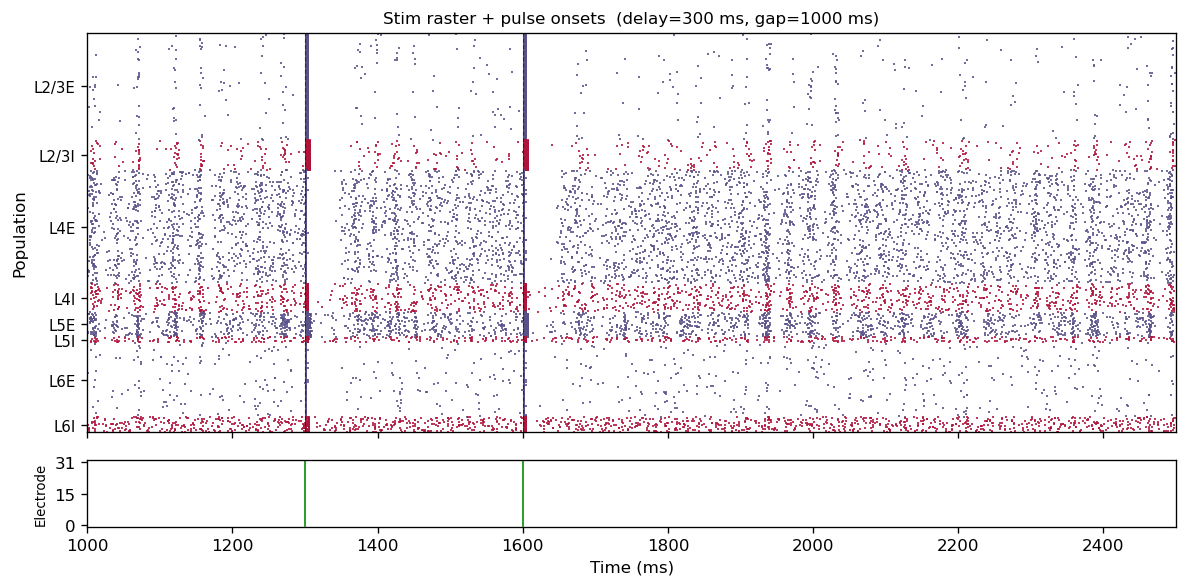

  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_300ms/raster_baseline_vs_stim_300ms.png


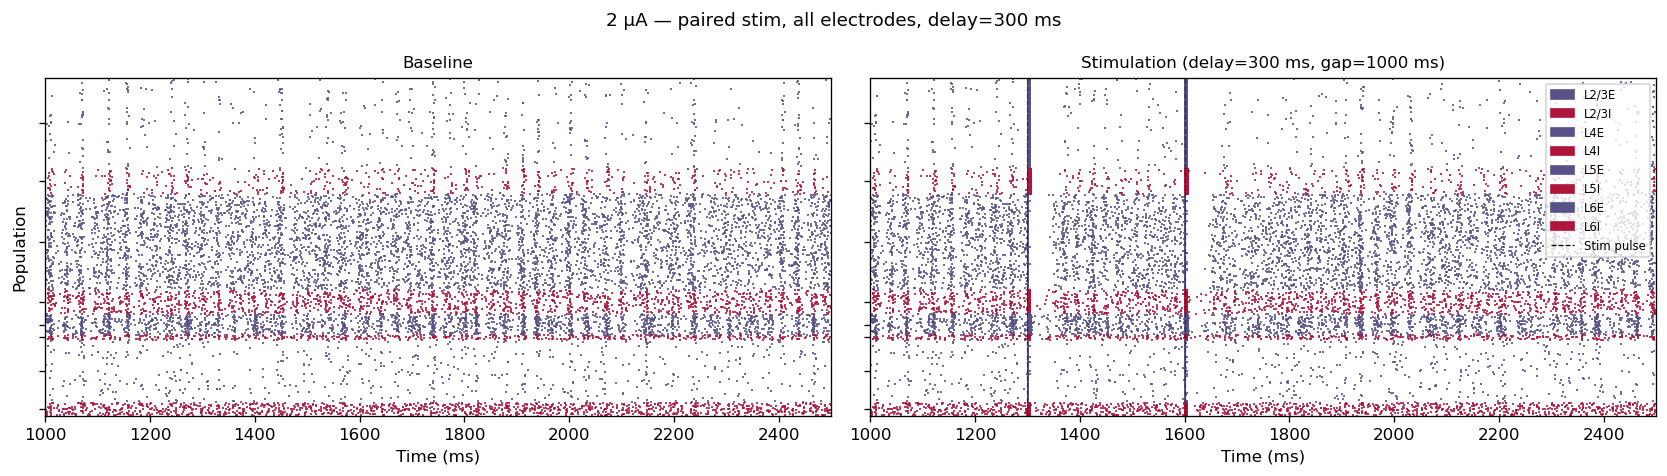


Done.


In [119]:
for seq_delay_ms in SEQ_DELAY_MS_LIST:
    stim_path = os.path.join(base_path, f"data_detstim_paired_{seq_delay_ms}ms")

    if not os.path.isdir(stim_path):
        print(f"[skip] {stim_path} not found")
        continue

    print(f"\n── delay = {seq_delay_ms} ms ──────────────────────────────────")

    # ── Load stim spike trains ────────────────────────────────────────────────
    stim_spk_trains, _ = load_spike_train_list(stim_path)
    stim_pops = get_population_spikes(stim_spk_trains, node_ids, RASTER_INTERVAL)

    # ── Load stim pulse times ─────────────────────────────────────────────────
    with open(os.path.join(stim_path, "stim_pulses.pkl"), "rb") as f:
        stim_onset_times_by_ch = pickle.load(f)

    all_pulse_times = np.unique(np.concatenate(list(stim_onset_times_by_ch.values())))
    window_pulses = all_pulse_times[
        (all_pulse_times >= RASTER_INTERVAL[0]) &
        (all_pulse_times <= RASTER_INTERVAL[1])
    ]

    # ── Figure 1: Stim raster + electrode sub-raster ─────────────────────────
    fig1, axes1 = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                               gridspec_kw={"height_ratios": [6, 1]})

    plot_raster_ax(axes1[0], stim_pops, ytick_pos, ylim_overall,
                   title=f"Stim raster + pulse onsets  (delay={seq_delay_ms} ms, gap={GAP_MS} ms)",
                   xlabel=False)
    for t in window_pulses:
        axes1[0].axvline(t, color="k", linewidth=0.7, alpha=0.5, linestyle="--")

    n_ch = 32
    for ch in range(n_ch):
        ch_pulses = np.array(stim_onset_times_by_ch.get(ch, []))
        ch_pulses = ch_pulses[(ch_pulses >= RASTER_INTERVAL[0]) & (ch_pulses <= RASTER_INTERVAL[1])]
        axes1[1].plot(ch_pulses, np.full(len(ch_pulses), ch), "|",
                      color="#2ca02c", markersize=4, linewidth=1)

    axes1[1].set_xlim(RASTER_INTERVAL)
    axes1[1].set_ylabel("Electrode", fontsize=8)
    axes1[1].set_xlabel("Time (ms)")
    axes1[1].set_ylim(-1, n_ch)
    axes1[1].set_yticks([0, 15, 31])
    plt.tight_layout()

    save1 = os.path.join(stim_path, f"raster_stim_pulses_{seq_delay_ms}ms.png")
    fig1.savefig(save1, dpi=150)
    print(f"  Saved → {save1}")
    plt.show()

    # ── Figure 2: Baseline vs Stim side-by-side ───────────────────────────────
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    plot_raster_ax(axes2[0], baseline_pops, ytick_pos, ylim_overall, title="Baseline")
    axes2[0].set_ylabel("Population")

    plot_raster_ax(axes2[1], stim_pops, ytick_pos, ylim_overall,
                   title=f"Stimulation (delay={seq_delay_ms} ms, gap={GAP_MS} ms)")
    axes2[1].set_ylabel("")
    axes2[1].set_yticklabels([])

    for t in window_pulses:
        axes2[1].axvline(t, color="k", linewidth=0.8, alpha=0.45, linestyle="--")

    handles = [mpatches.Patch(color=c, label=l) for c, l in zip(POP_COLORS, POP_LABELS)]
    handles.append(plt.Line2D([0], [0], color="k", linestyle="--", linewidth=0.8, label="Stim pulse"))
    axes2[1].legend(handles=handles, loc="upper right", fontsize=7, ncol=1)

    plt.suptitle(f"{stim_amp} µA — paired stim, all electrodes, delay={seq_delay_ms} ms", fontsize=11)
    plt.tight_layout()

    save2 = os.path.join(stim_path, f"raster_baseline_vs_stim_{seq_delay_ms}ms.png")
    fig2.savefig(save2, dpi=150)
    print(f"  Saved → {save2}")
    plt.show()
    plt.close("all")

print("\nDone.")

In [120]:
stim_onset_times_by_ch

{np.int64(0): [np.float64(0.0),
  np.float64(300.0),
  np.float64(1300.0),
  np.float64(1600.0),
  np.float64(2600.0),
  np.float64(2900.0),
  np.float64(3900.0),
  np.float64(4200.0),
  np.float64(5200.0),
  np.float64(5500.0),
  np.float64(6500.0),
  np.float64(6800.0),
  np.float64(7800.0),
  np.float64(8100.0),
  np.float64(9100.0),
  np.float64(9400.0),
  np.float64(10400.0),
  np.float64(10700.0),
  np.float64(11700.0),
  np.float64(12000.0),
  np.float64(13000.0),
  np.float64(13300.0),
  np.float64(14300.0),
  np.float64(14600.0),
  np.float64(15600.0),
  np.float64(15900.0),
  np.float64(16900.0),
  np.float64(17200.0),
  np.float64(18200.0),
  np.float64(18500.0),
  np.float64(19500.0),
  np.float64(19800.0),
  np.float64(20800.0),
  np.float64(21100.0),
  np.float64(22100.0),
  np.float64(22400.0),
  np.float64(23400.0),
  np.float64(23700.0),
  np.float64(24700.0),
  np.float64(25000.0),
  np.float64(26000.0),
  np.float64(26300.0),
  np.float64(27300.0),
  np.float64(27600

## 7 — Average Activation Pattern per Stimulation Pair

For each delay condition:
- Identify the start of every stimulation pair (absolute time = `PRESIM_TIME_MS + k * (delay + gap)`)
- Extract a spike-count snippet per neuron over the pair window `[pair_start, pair_start + delay + gap)`
- Average snippets across all pairs → mean firing rate trace per neuron
- Plot as a heatmap (neurons × time) with neurons sorted by population


── delay = 0 ms ──────────────────────────────────
  pair_period=1000 ms,  n_pairs=60
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_0ms/avg_activation_heatmap_0ms.png


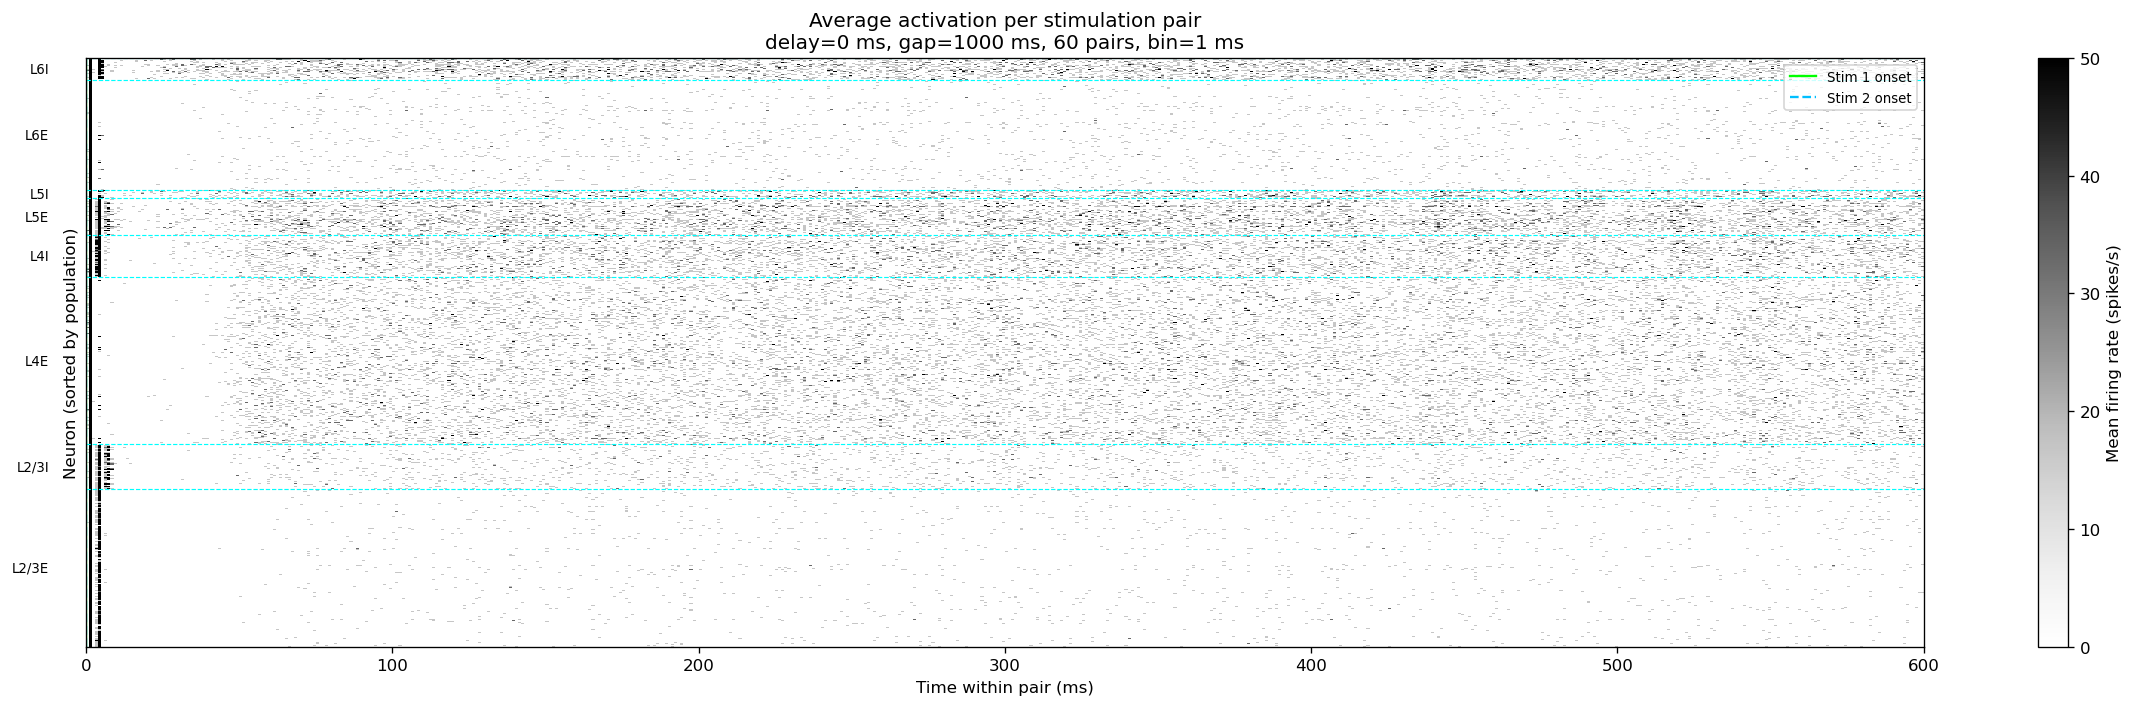


── delay = 5 ms ──────────────────────────────────
  pair_period=1005 ms,  n_pairs=60
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_5ms/avg_activation_heatmap_5ms.png


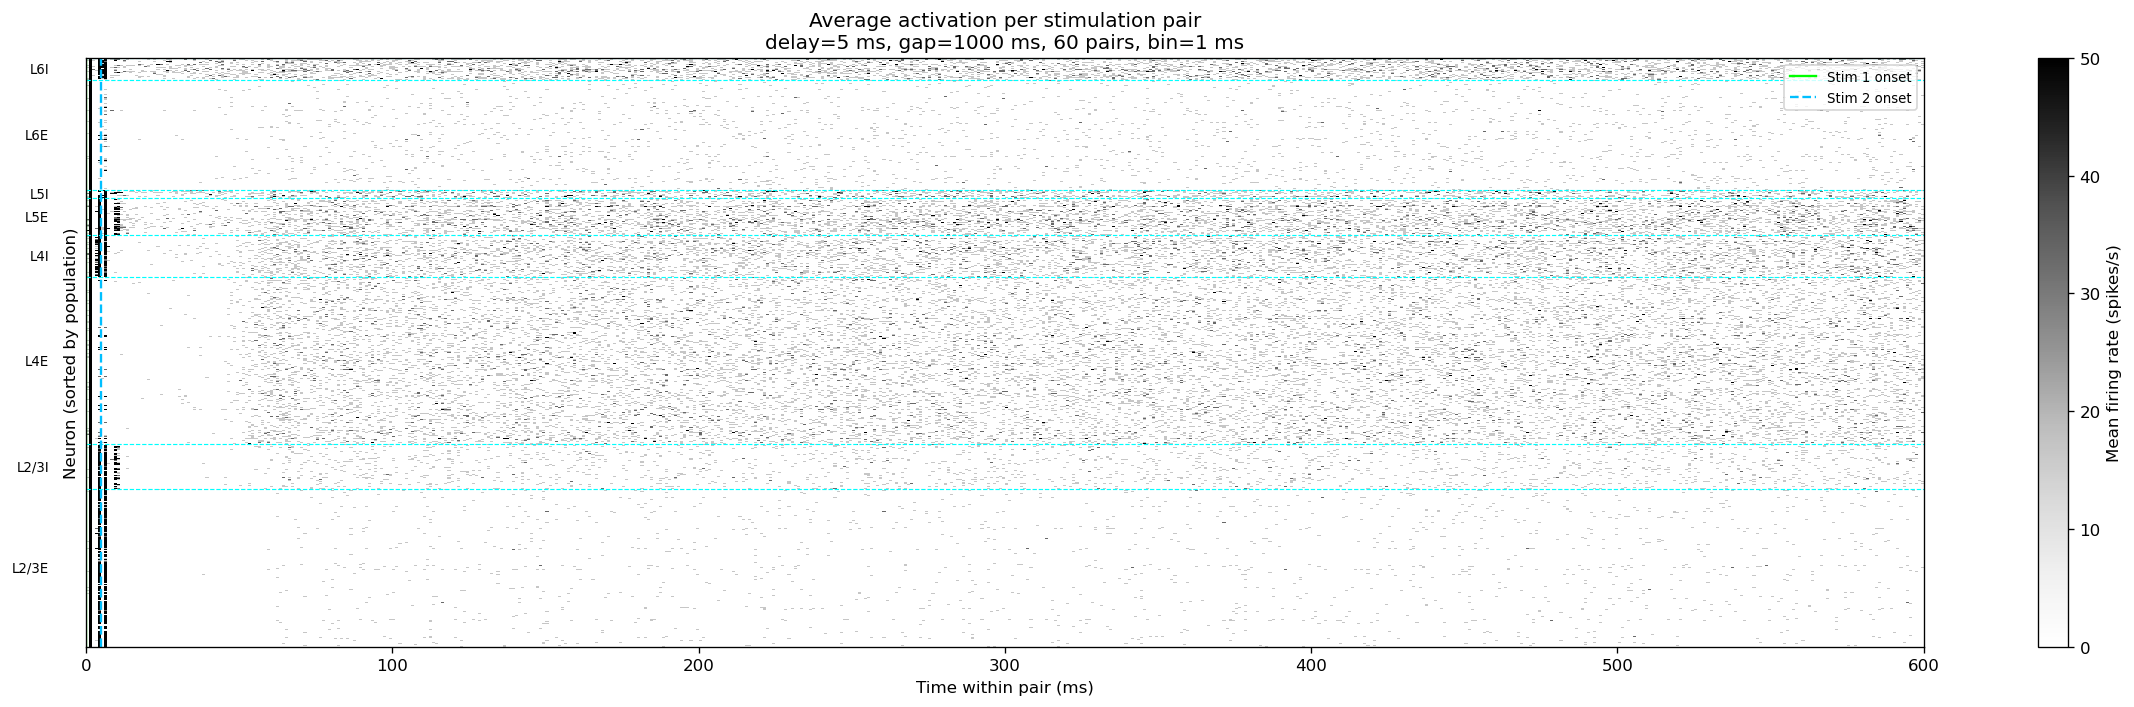


── delay = 10 ms ──────────────────────────────────
  pair_period=1010 ms,  n_pairs=60
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_10ms/avg_activation_heatmap_10ms.png


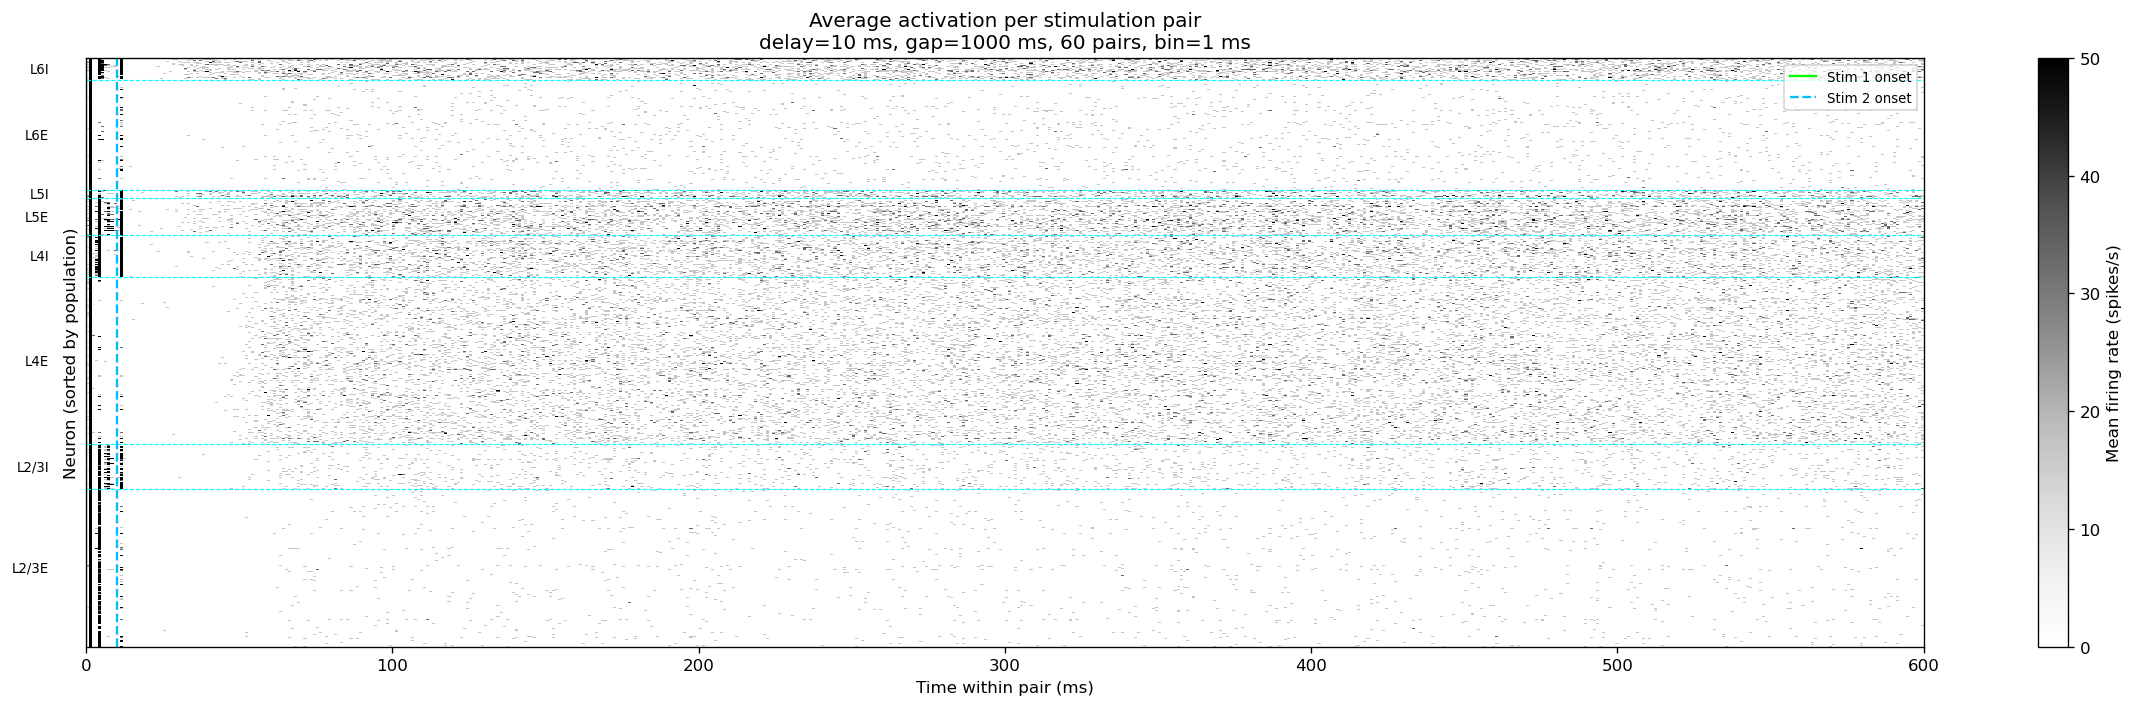


── delay = 20 ms ──────────────────────────────────
  pair_period=1020 ms,  n_pairs=59
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_20ms/avg_activation_heatmap_20ms.png


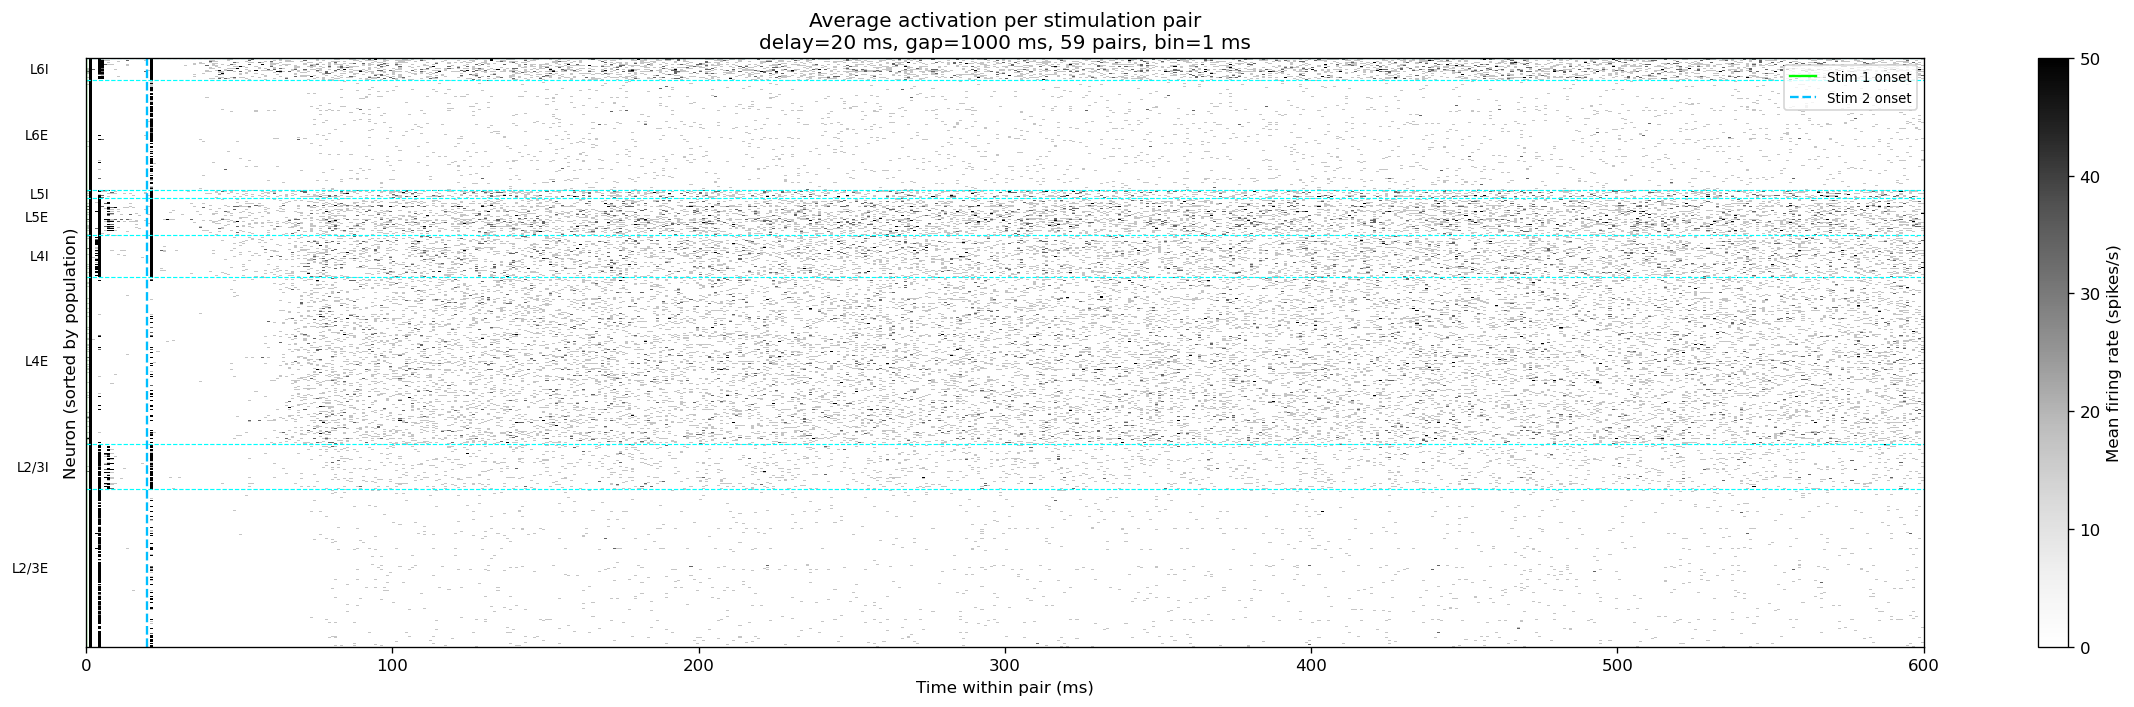


── delay = 30 ms ──────────────────────────────────
  pair_period=1030 ms,  n_pairs=59
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_30ms/avg_activation_heatmap_30ms.png


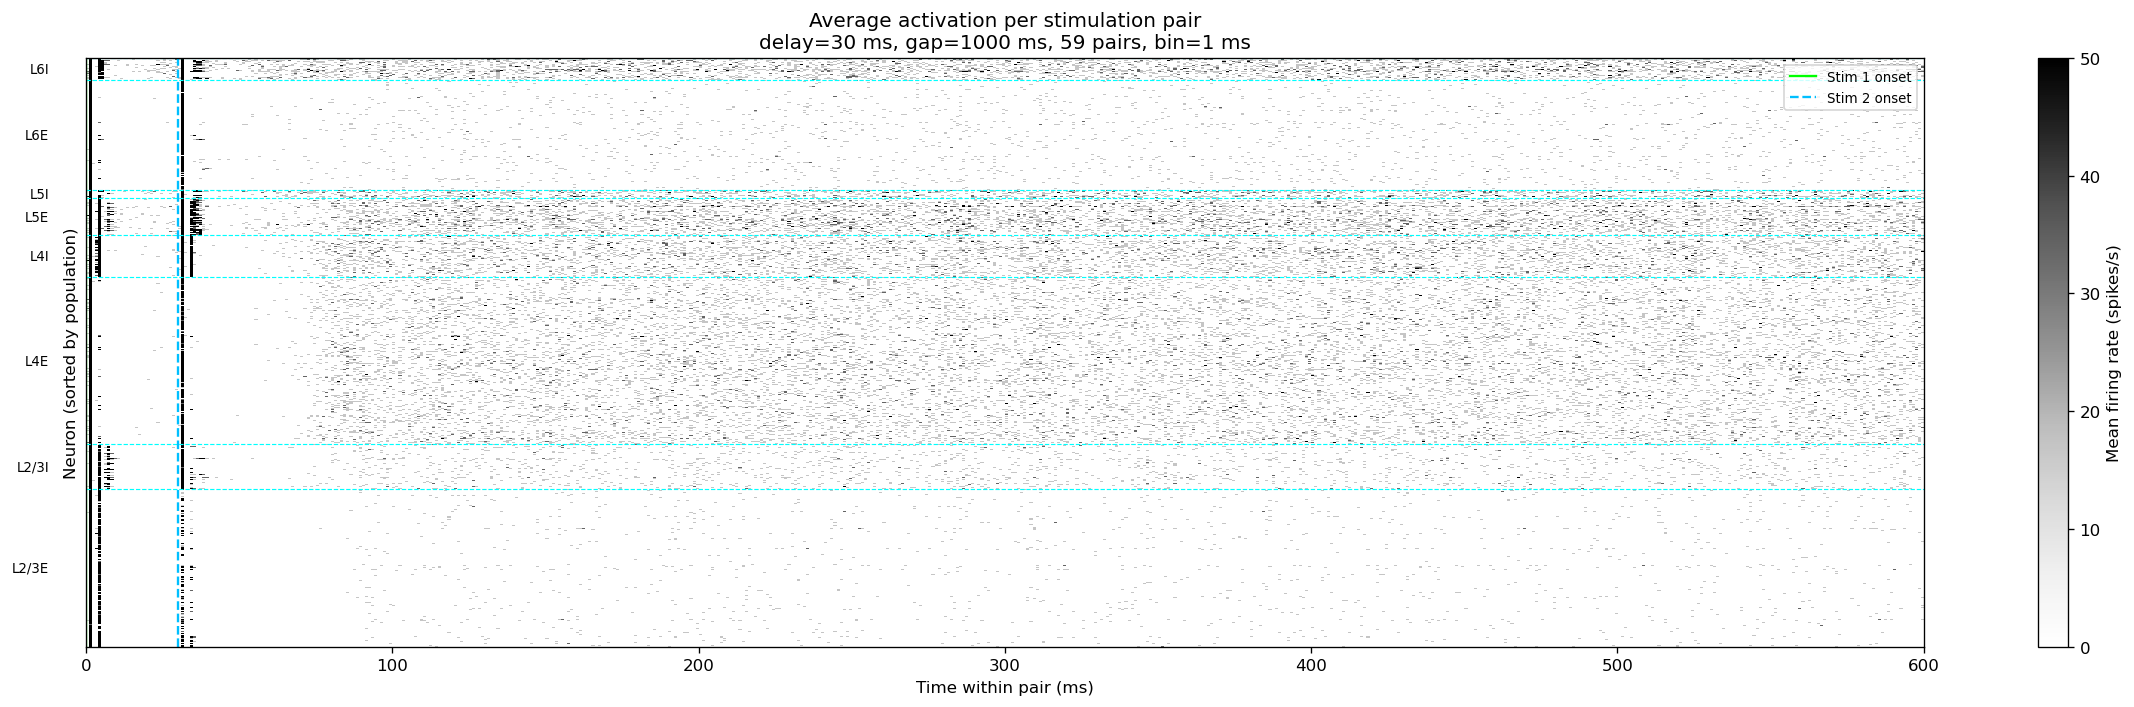


── delay = 40 ms ──────────────────────────────────
  pair_period=1040 ms,  n_pairs=58
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_40ms/avg_activation_heatmap_40ms.png


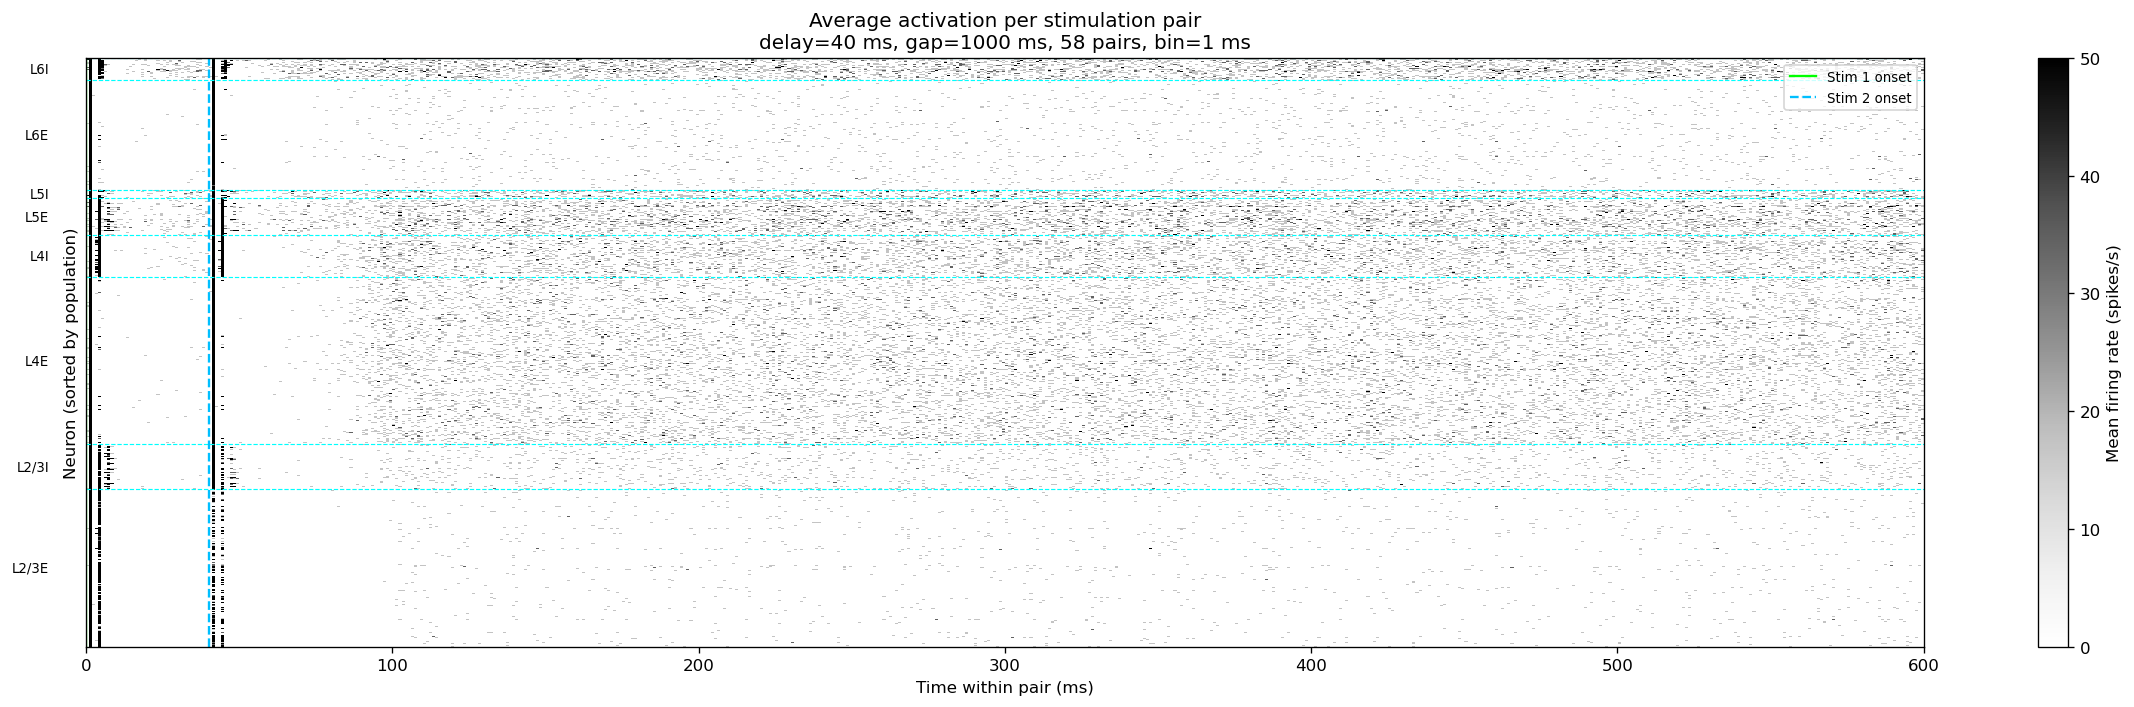


── delay = 50 ms ──────────────────────────────────
  pair_period=1050 ms,  n_pairs=58
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_50ms/avg_activation_heatmap_50ms.png


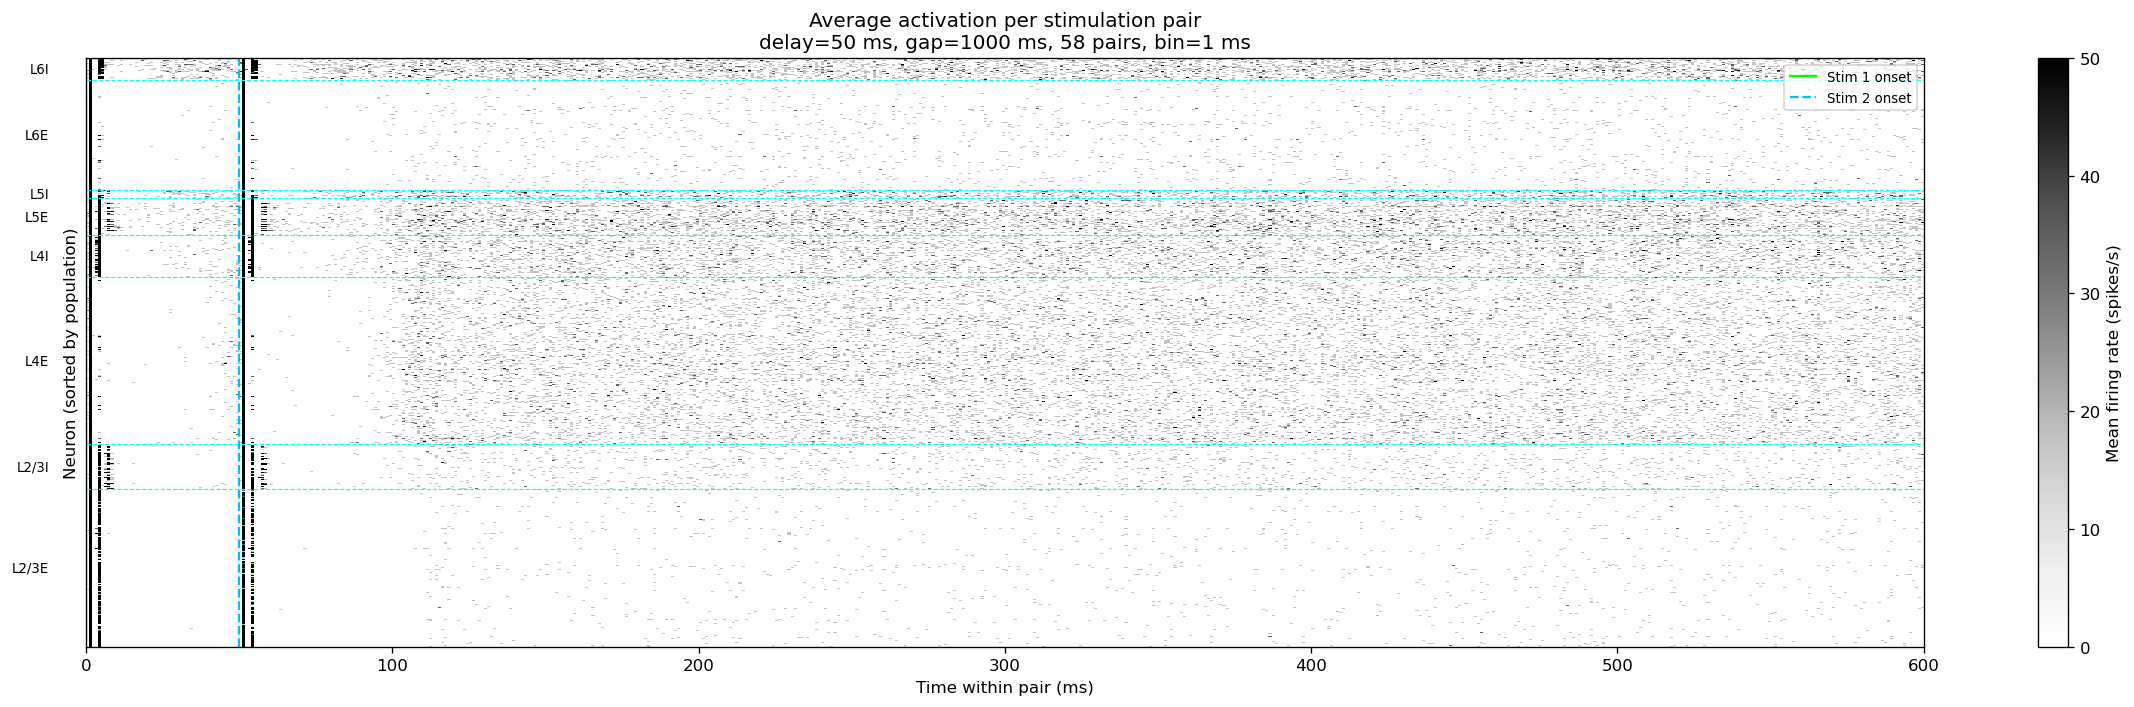


── delay = 100 ms ──────────────────────────────────
  pair_period=1100 ms,  n_pairs=55
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_100ms/avg_activation_heatmap_100ms.png


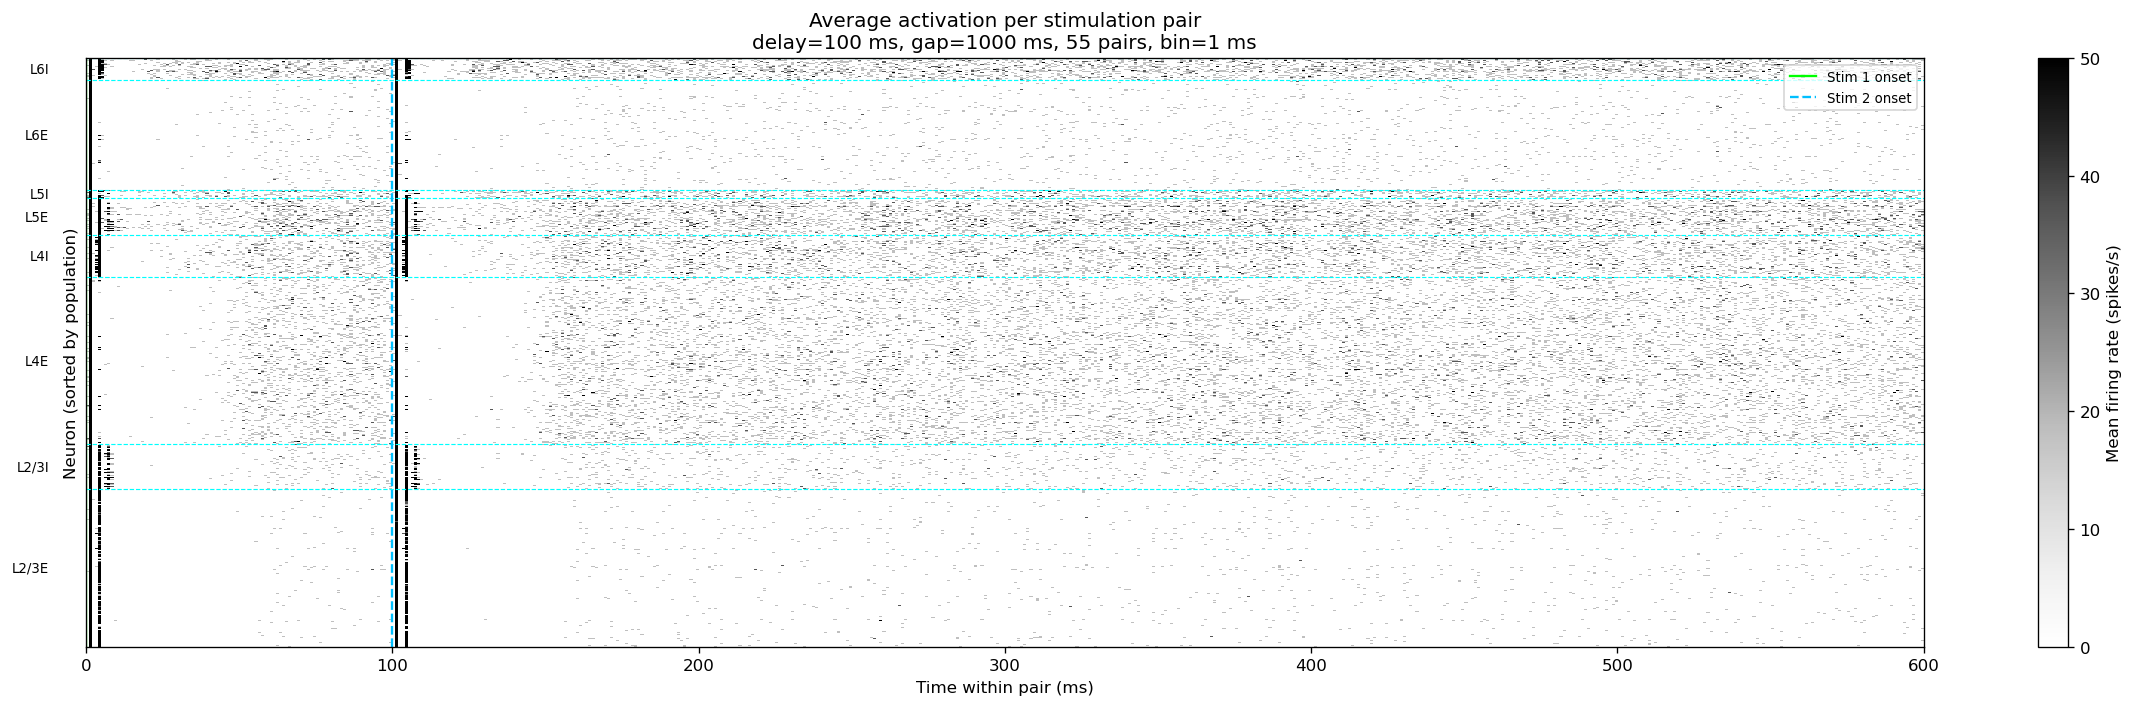


── delay = 200 ms ──────────────────────────────────
  pair_period=1200 ms,  n_pairs=50
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_200ms/avg_activation_heatmap_200ms.png


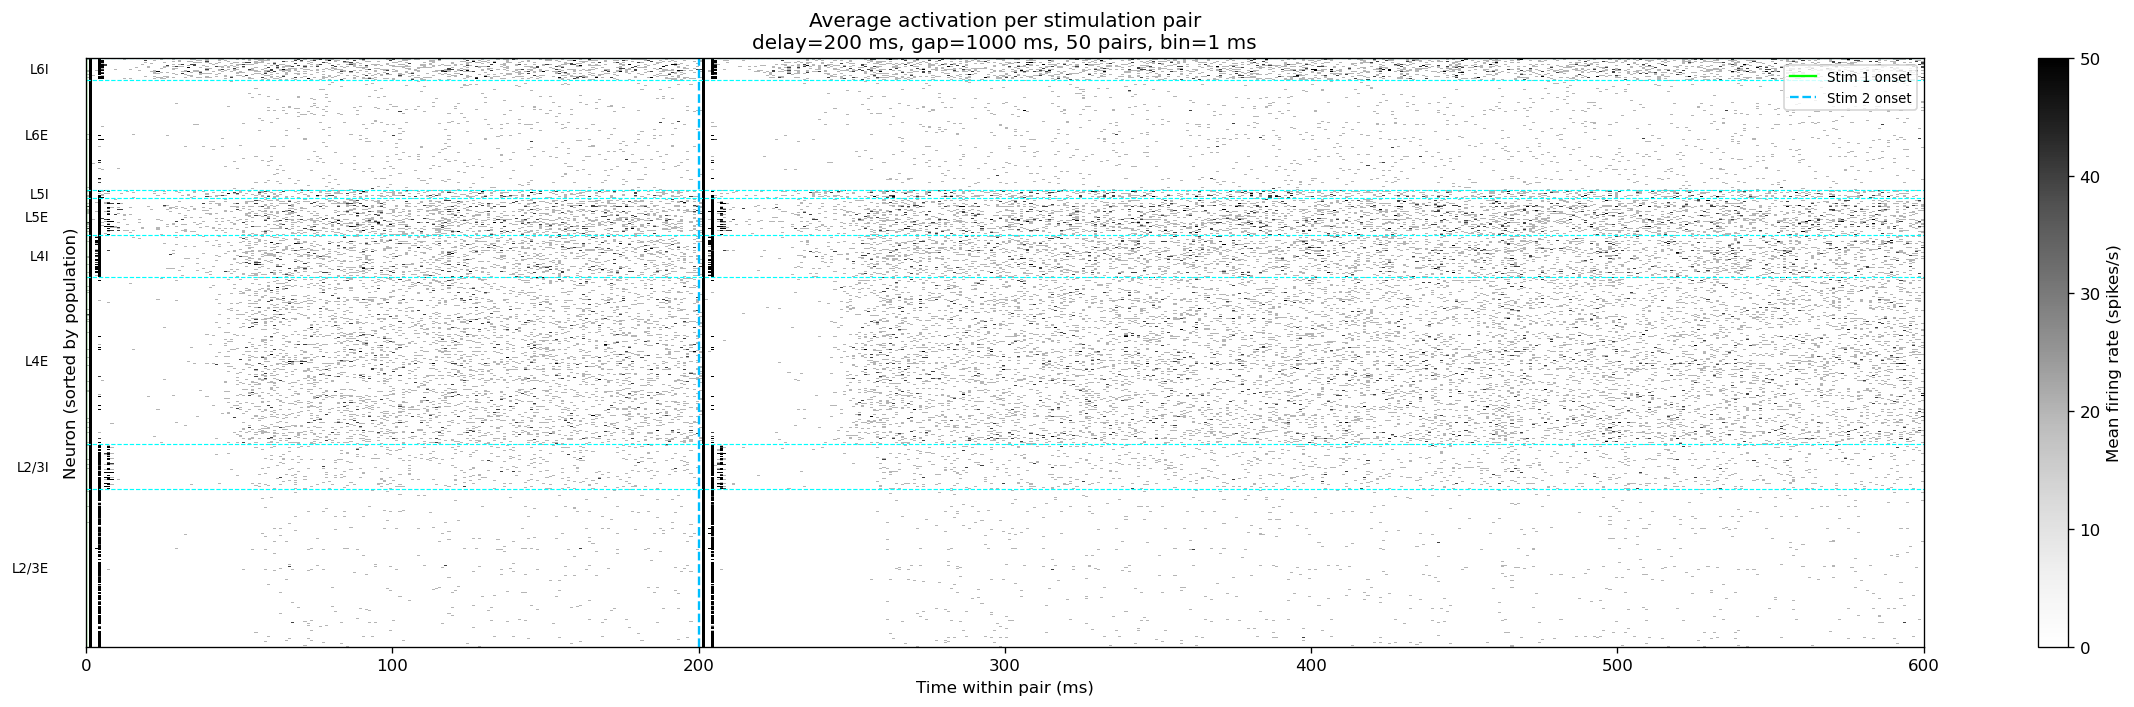


── delay = 300 ms ──────────────────────────────────
  pair_period=1300 ms,  n_pairs=47
  Saved → /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_multi_delay_0.05scale_2uA_60s/data_detstim_paired_300ms/avg_activation_heatmap_300ms.png


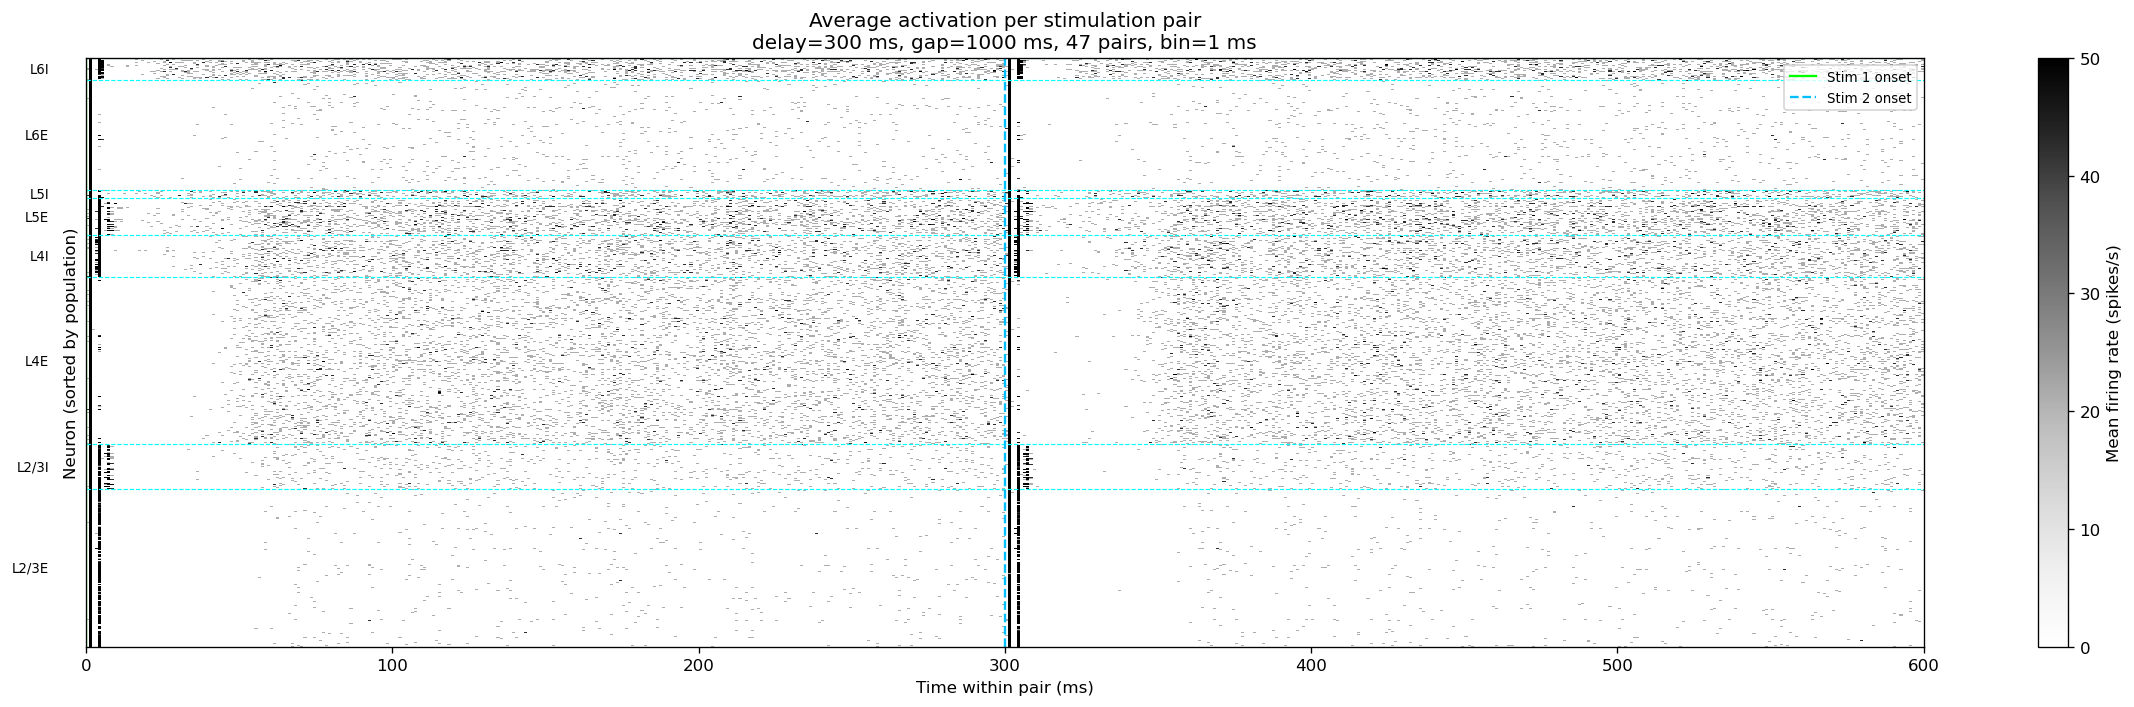


Done.


In [124]:

# ── Parameters ────────────────────────────────────────────────────────────────
BIN_MS = 1   # ms — time-bin width for the spike-count histogram

for seq_delay_ms in SEQ_DELAY_MS_LIST:
    stim_path = os.path.join(base_path, f"data_detstim_paired_{seq_delay_ms}ms")
    if not os.path.isdir(stim_path):
        print(f"[skip] {stim_path} not found")
        continue

    print(f"\n── delay = {seq_delay_ms} ms ──────────────────────────────────")

    # ── Load stim spike trains ────────────────────────────────────────────────
    stim_spk_trains, _ = load_spike_train_list(stim_path)
    n_neurons = len(stim_spk_trains)

    # ── Identify pair start times (one pair every delay + gap ms) ────────────
    pair_period_ms = seq_delay_ms + GAP_MS
    pair_starts = np.arange(
        PRESIM_TIME_MS,
        PRESIM_TIME_MS + SIM_TIME_MS,
        pair_period_ms,
    ) + seq_delay_ms
    n_pairs = len(pair_starts)
    print(f"  pair_period={pair_period_ms} ms,  n_pairs={n_pairs}")

    # ── Time bins within a single snippet ─────────────────────────────────────
    bin_edges = np.arange(0, pair_period_ms + BIN_MS, BIN_MS)
    n_bins    = len(bin_edges) - 1

    # ── Accumulate spike counts across pairs: shape (n_neurons, n_bins) ───────
    spike_sum = np.zeros((n_neurons, n_bins))
    for t0 in pair_starts:
        t1 = t0 + pair_period_ms
        for nid, st in enumerate(stim_spk_trains):
            if len(st) == 0:
                continue
            rel  = st - t0
            mask = (rel >= 0) & (rel < pair_period_ms)
            if mask.any():
                counts, _ = np.histogram(rel[mask], bins=bin_edges)
                spike_sum[nid] += counts

    # Mean spike count per bin; convert to mean firing rate (spikes/s)
    mean_rate = (spike_sum / n_pairs) / (BIN_MS * 1e-3)   # Hz

    # ── Sort neurons by population (population order, low→high neuron_id) ─────
    last_node_id = node_ids[-1, -1]
    pop_order      = []   # 0-based neuron indices in population order
    pop_boundaries = []
    for i in range(len(node_ids)):
        nid_lo = int(last_node_id - node_ids[i, 1] + 1)
        nid_hi = int(last_node_id - node_ids[i, 0] + 1)
        pop_order.extend(range(nid_lo - 1, nid_hi))   # 0-based
        pop_boundaries.append(len(pop_order))

    mean_rate_sorted = mean_rate[np.array(pop_order), :]

    # ── Plot heatmap ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(20, 6))

    im = ax.imshow(
        mean_rate_sorted,
        aspect="auto",
        interpolation="none",
        origin="lower",
        extent=[bin_edges[0], bin_edges[-1], 0, len(pop_order)],
        cmap="Greys",
        vmin=0,
        vmax=50,
    )
    plt.xlim([0, 600])
    plt.yticks([])
    plt.colorbar(im, ax=ax, label="Mean firing rate (spikes/s)")

    # Population boundary lines and labels
    prev = 0
    for i, bnd in enumerate(pop_boundaries):
        ax.axhline(bnd, color="cyan", linewidth=0.7, linestyle="--")
        ax.text(
            -0.02, (prev + bnd) / 2 / len(pop_order),
            POP_LABELS[i],
            va="center", ha="right", fontsize=8,
            transform=ax.transAxes,
        )
        prev = bnd

    # Stim pulse markers relative to pair start
    ax.axvline(0,            color="lime",        linewidth=1.4, linestyle="-",  label="Stim 1 onset")
    ax.axvline(seq_delay_ms, color="deepskyblue", linewidth=1.4, linestyle="--", label="Stim 2 onset")

    ax.set_xlabel("Time within pair (ms)")
    ax.set_ylabel("Neuron (sorted by population)")
    ax.set_title(
        f"Average activation per stimulation pair\n"
        f"delay={seq_delay_ms} ms, gap={GAP_MS} ms, {n_pairs} pairs, bin={BIN_MS} ms"
    )
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()

    save_path = os.path.join(stim_path, f"avg_activation_heatmap_{seq_delay_ms}ms.png")
    fig.savefig(save_path, dpi=150)
    print(f"  Saved → {save_path}")
    plt.show()
    plt.close("all")

print("\nDone.")


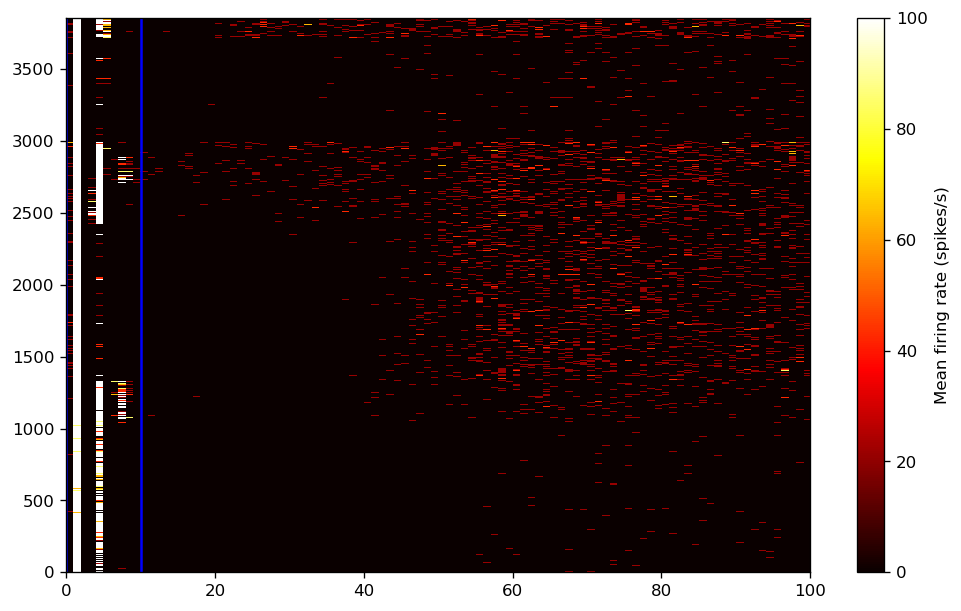

In [122]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    mean_rate_sorted,
    aspect="auto",
    interpolation="none",
    origin="lower",
    extent=[bin_edges[0], bin_edges[-1], 0, len(pop_order)],
    cmap="hot",
    vmin=0,
    vmax=100,
)
plt.colorbar(im, ax=ax, label="Mean firing rate (spikes/s)")
plt.xlim([0, 100])

plt.axvline(0, color='b')
plt.axvline(10, color='b')

In [123]:
stim_onset_times_by_ch

{np.int64(0): [np.float64(0.0),
  np.float64(300.0),
  np.float64(1300.0),
  np.float64(1600.0),
  np.float64(2600.0),
  np.float64(2900.0),
  np.float64(3900.0),
  np.float64(4200.0),
  np.float64(5200.0),
  np.float64(5500.0),
  np.float64(6500.0),
  np.float64(6800.0),
  np.float64(7800.0),
  np.float64(8100.0),
  np.float64(9100.0),
  np.float64(9400.0),
  np.float64(10400.0),
  np.float64(10700.0),
  np.float64(11700.0),
  np.float64(12000.0),
  np.float64(13000.0),
  np.float64(13300.0),
  np.float64(14300.0),
  np.float64(14600.0),
  np.float64(15600.0),
  np.float64(15900.0),
  np.float64(16900.0),
  np.float64(17200.0),
  np.float64(18200.0),
  np.float64(18500.0),
  np.float64(19500.0),
  np.float64(19800.0),
  np.float64(20800.0),
  np.float64(21100.0),
  np.float64(22100.0),
  np.float64(22400.0),
  np.float64(23400.0),
  np.float64(23700.0),
  np.float64(24700.0),
  np.float64(25000.0),
  np.float64(26000.0),
  np.float64(26300.0),
  np.float64(27300.0),
  np.float64(27600